In [42]:
# 导入必要的库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ysy_plot_test_version as yp

# 绘图设置
yp.ysy_settings()
# 配色
from matplotlib.colors import LinearSegmentedColormap
colors = yp.firefly()
cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)

# 其它
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
from scipy.signal import find_peaks

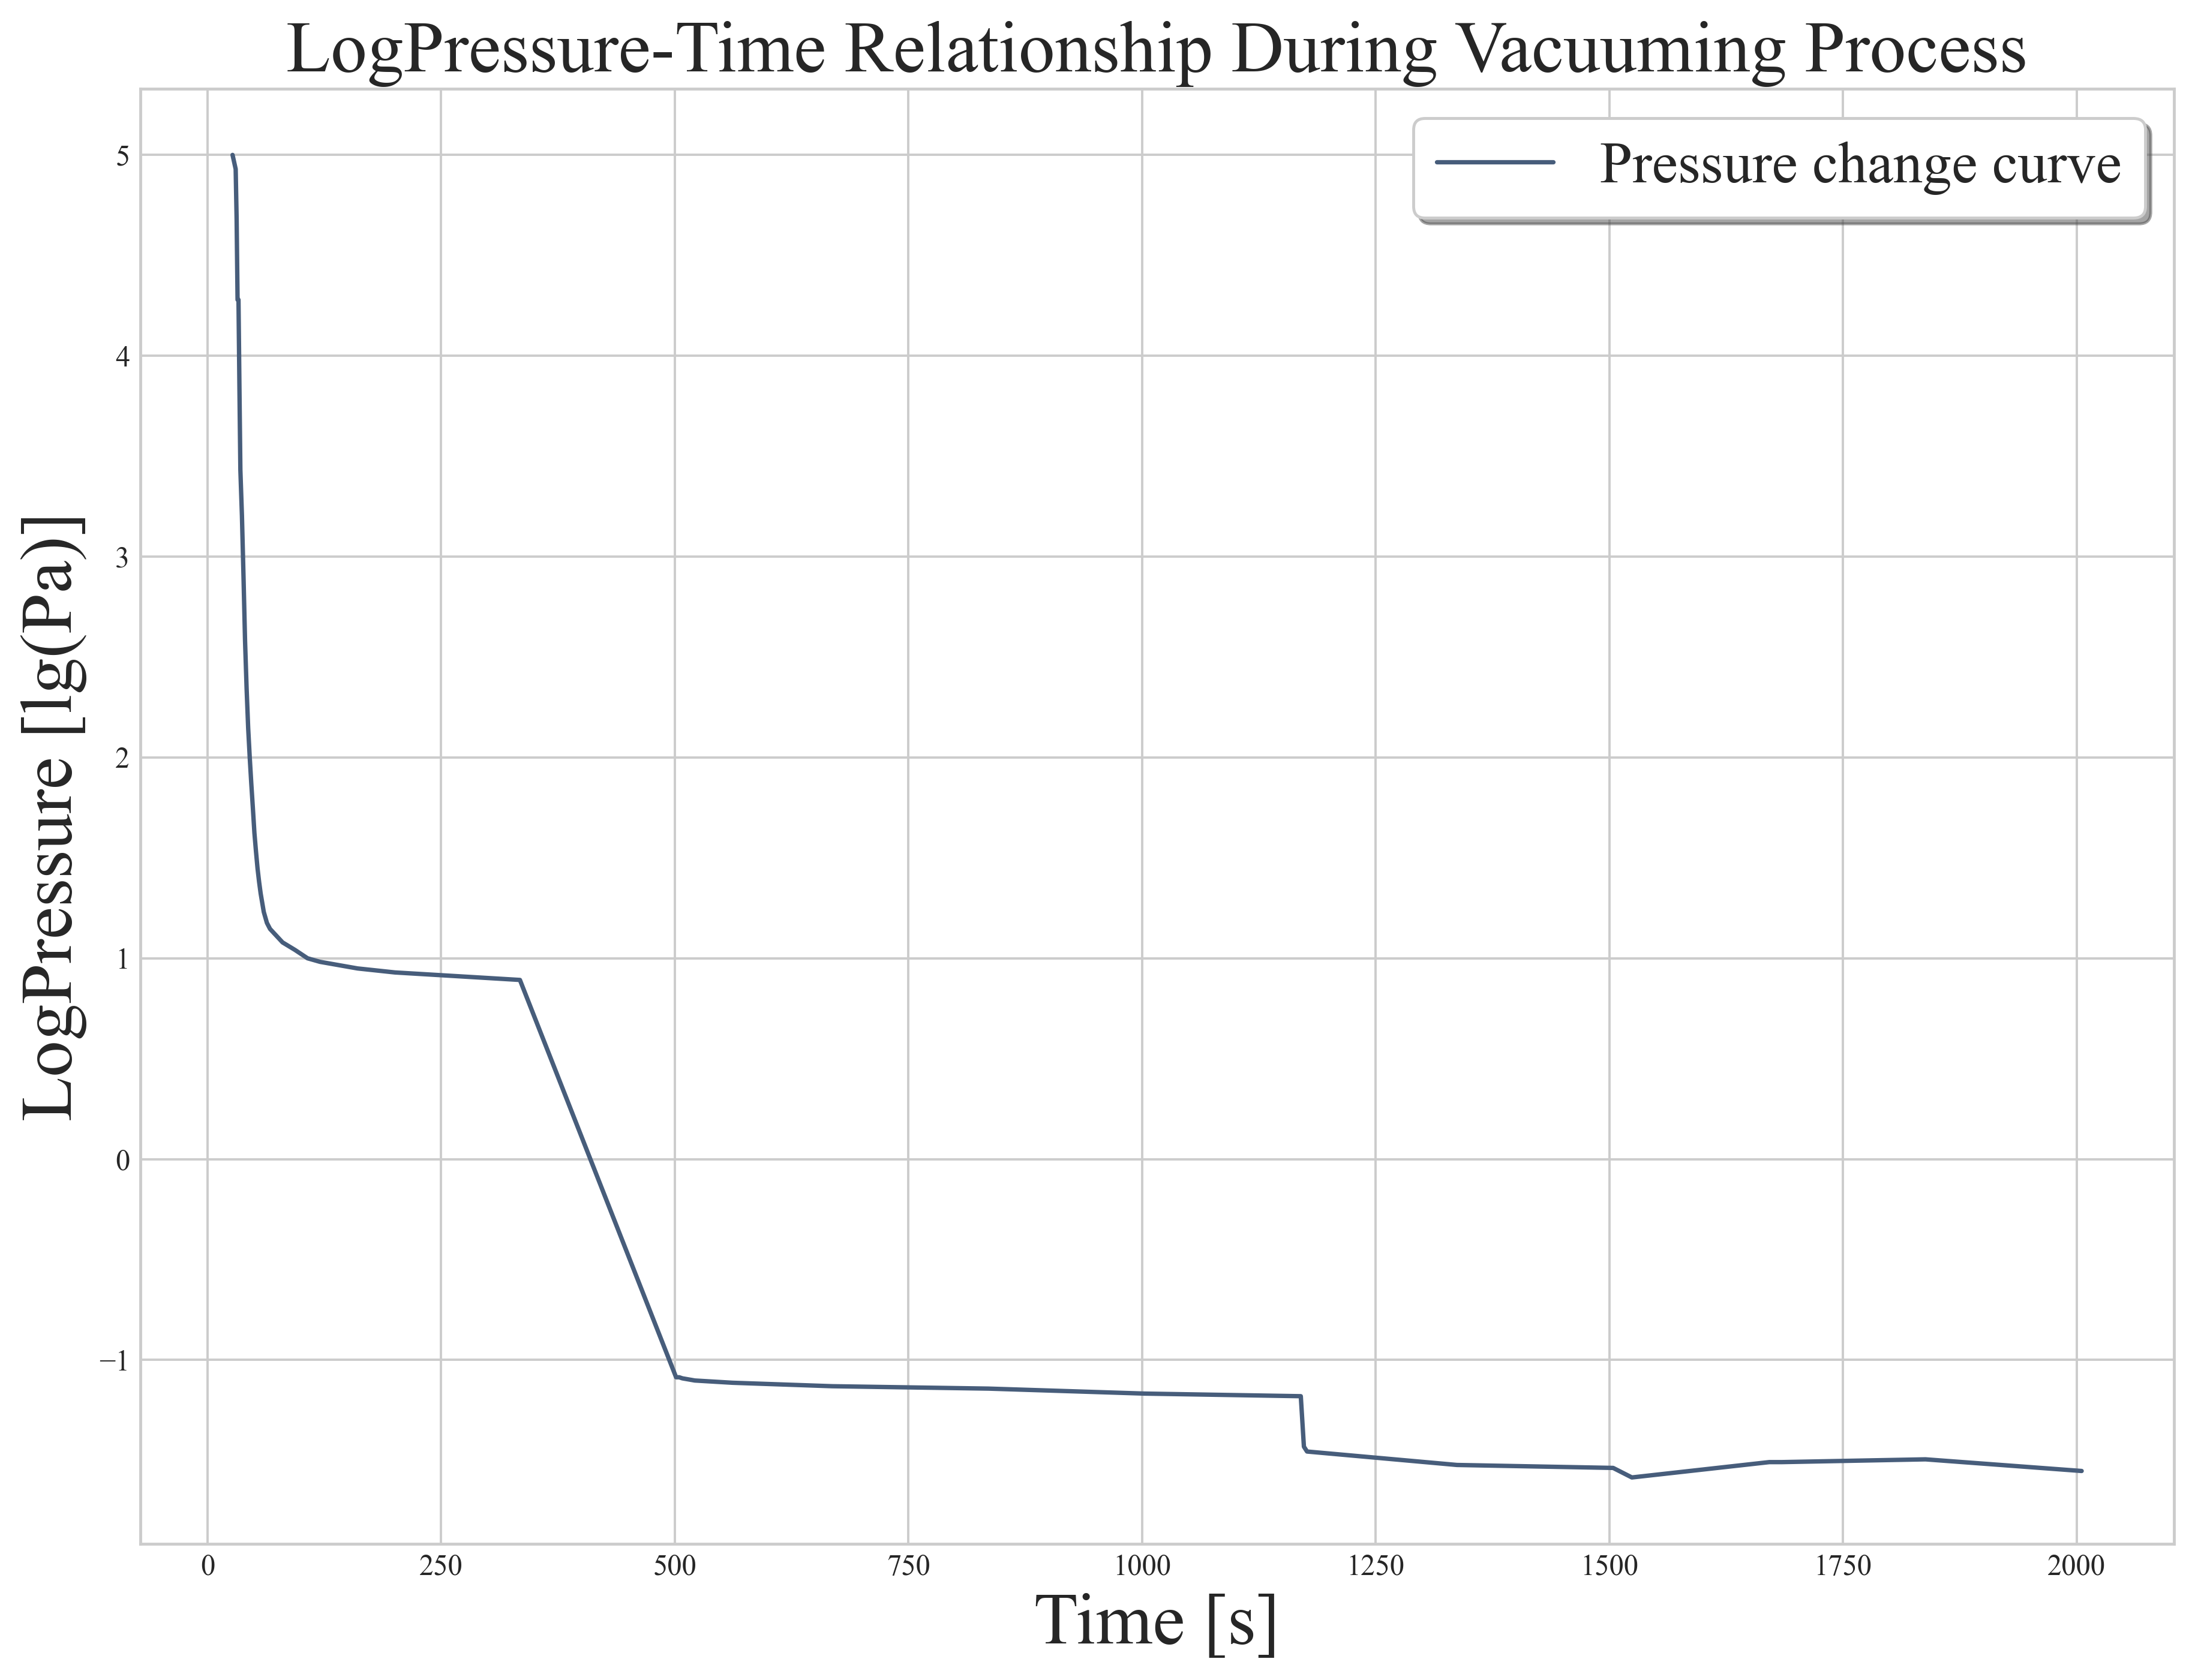

In [11]:
# 实验一
data1_down = pd.read_excel('Pressure-time_data.xlsx', sheet_name='Sheet1')
p1_down = data1_down['压强(Pa)'].values
t1_down = data1_down['时间(s)'].values
yp.std_plot(t1_down, np.log10(p1_down), 'Pressure change curve', plot_name='LogPressure-Time Relationship During Vacuuming Process', x_label='Time [s]', y_label='LogPressure [lg(Pa)]')

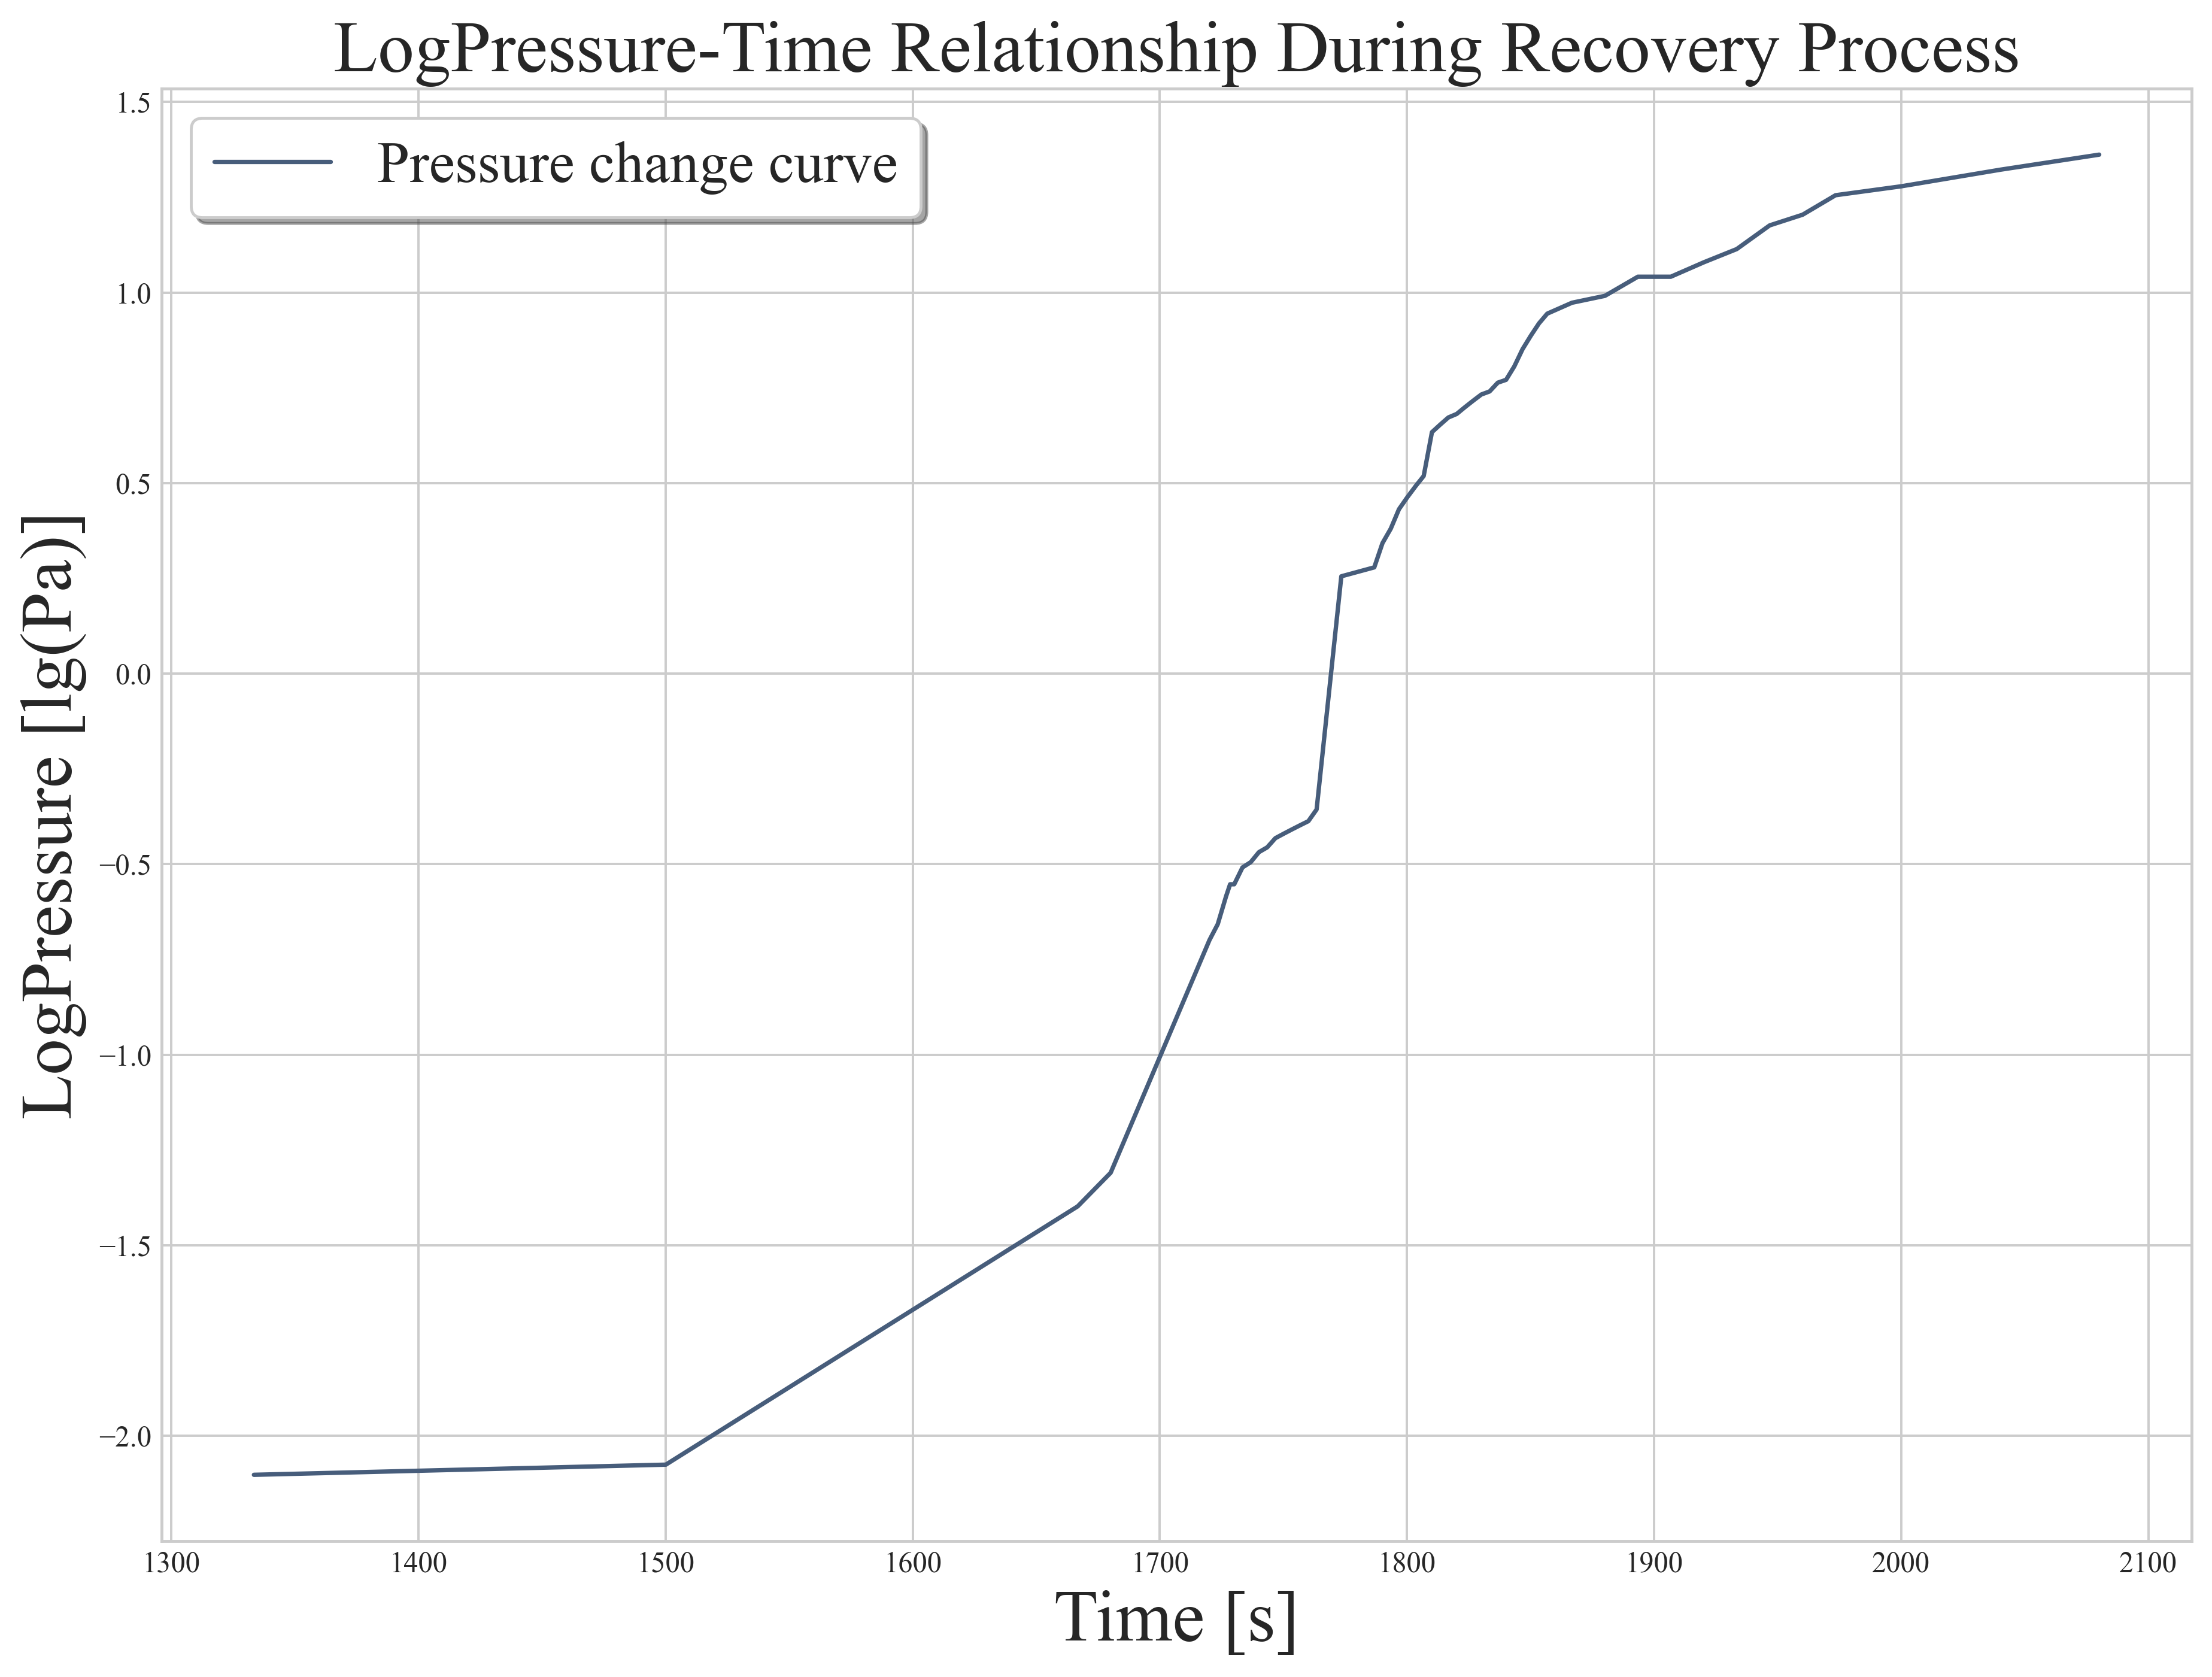

In [ ]:
data1_up = pd.read_excel('Pressure-time_data.xlsx', sheet_name='Sheet2')
p1_up = data1_up['压强(Pa)'].values
t1_up = data1_up['时间(s)'].values
p1_up = p1_up[2*len(p1_up)//5:]
t1_up = t1_up[2*len(t1_up)//5:]
yp.std_plot(t1_up, np.log10(p1_up), 'Pressure change curve', plot_name='LogPressure-Time Relationship During Recovery Process', x_label='Time [s]', y_label='LogPressure [lg(Pa)]')

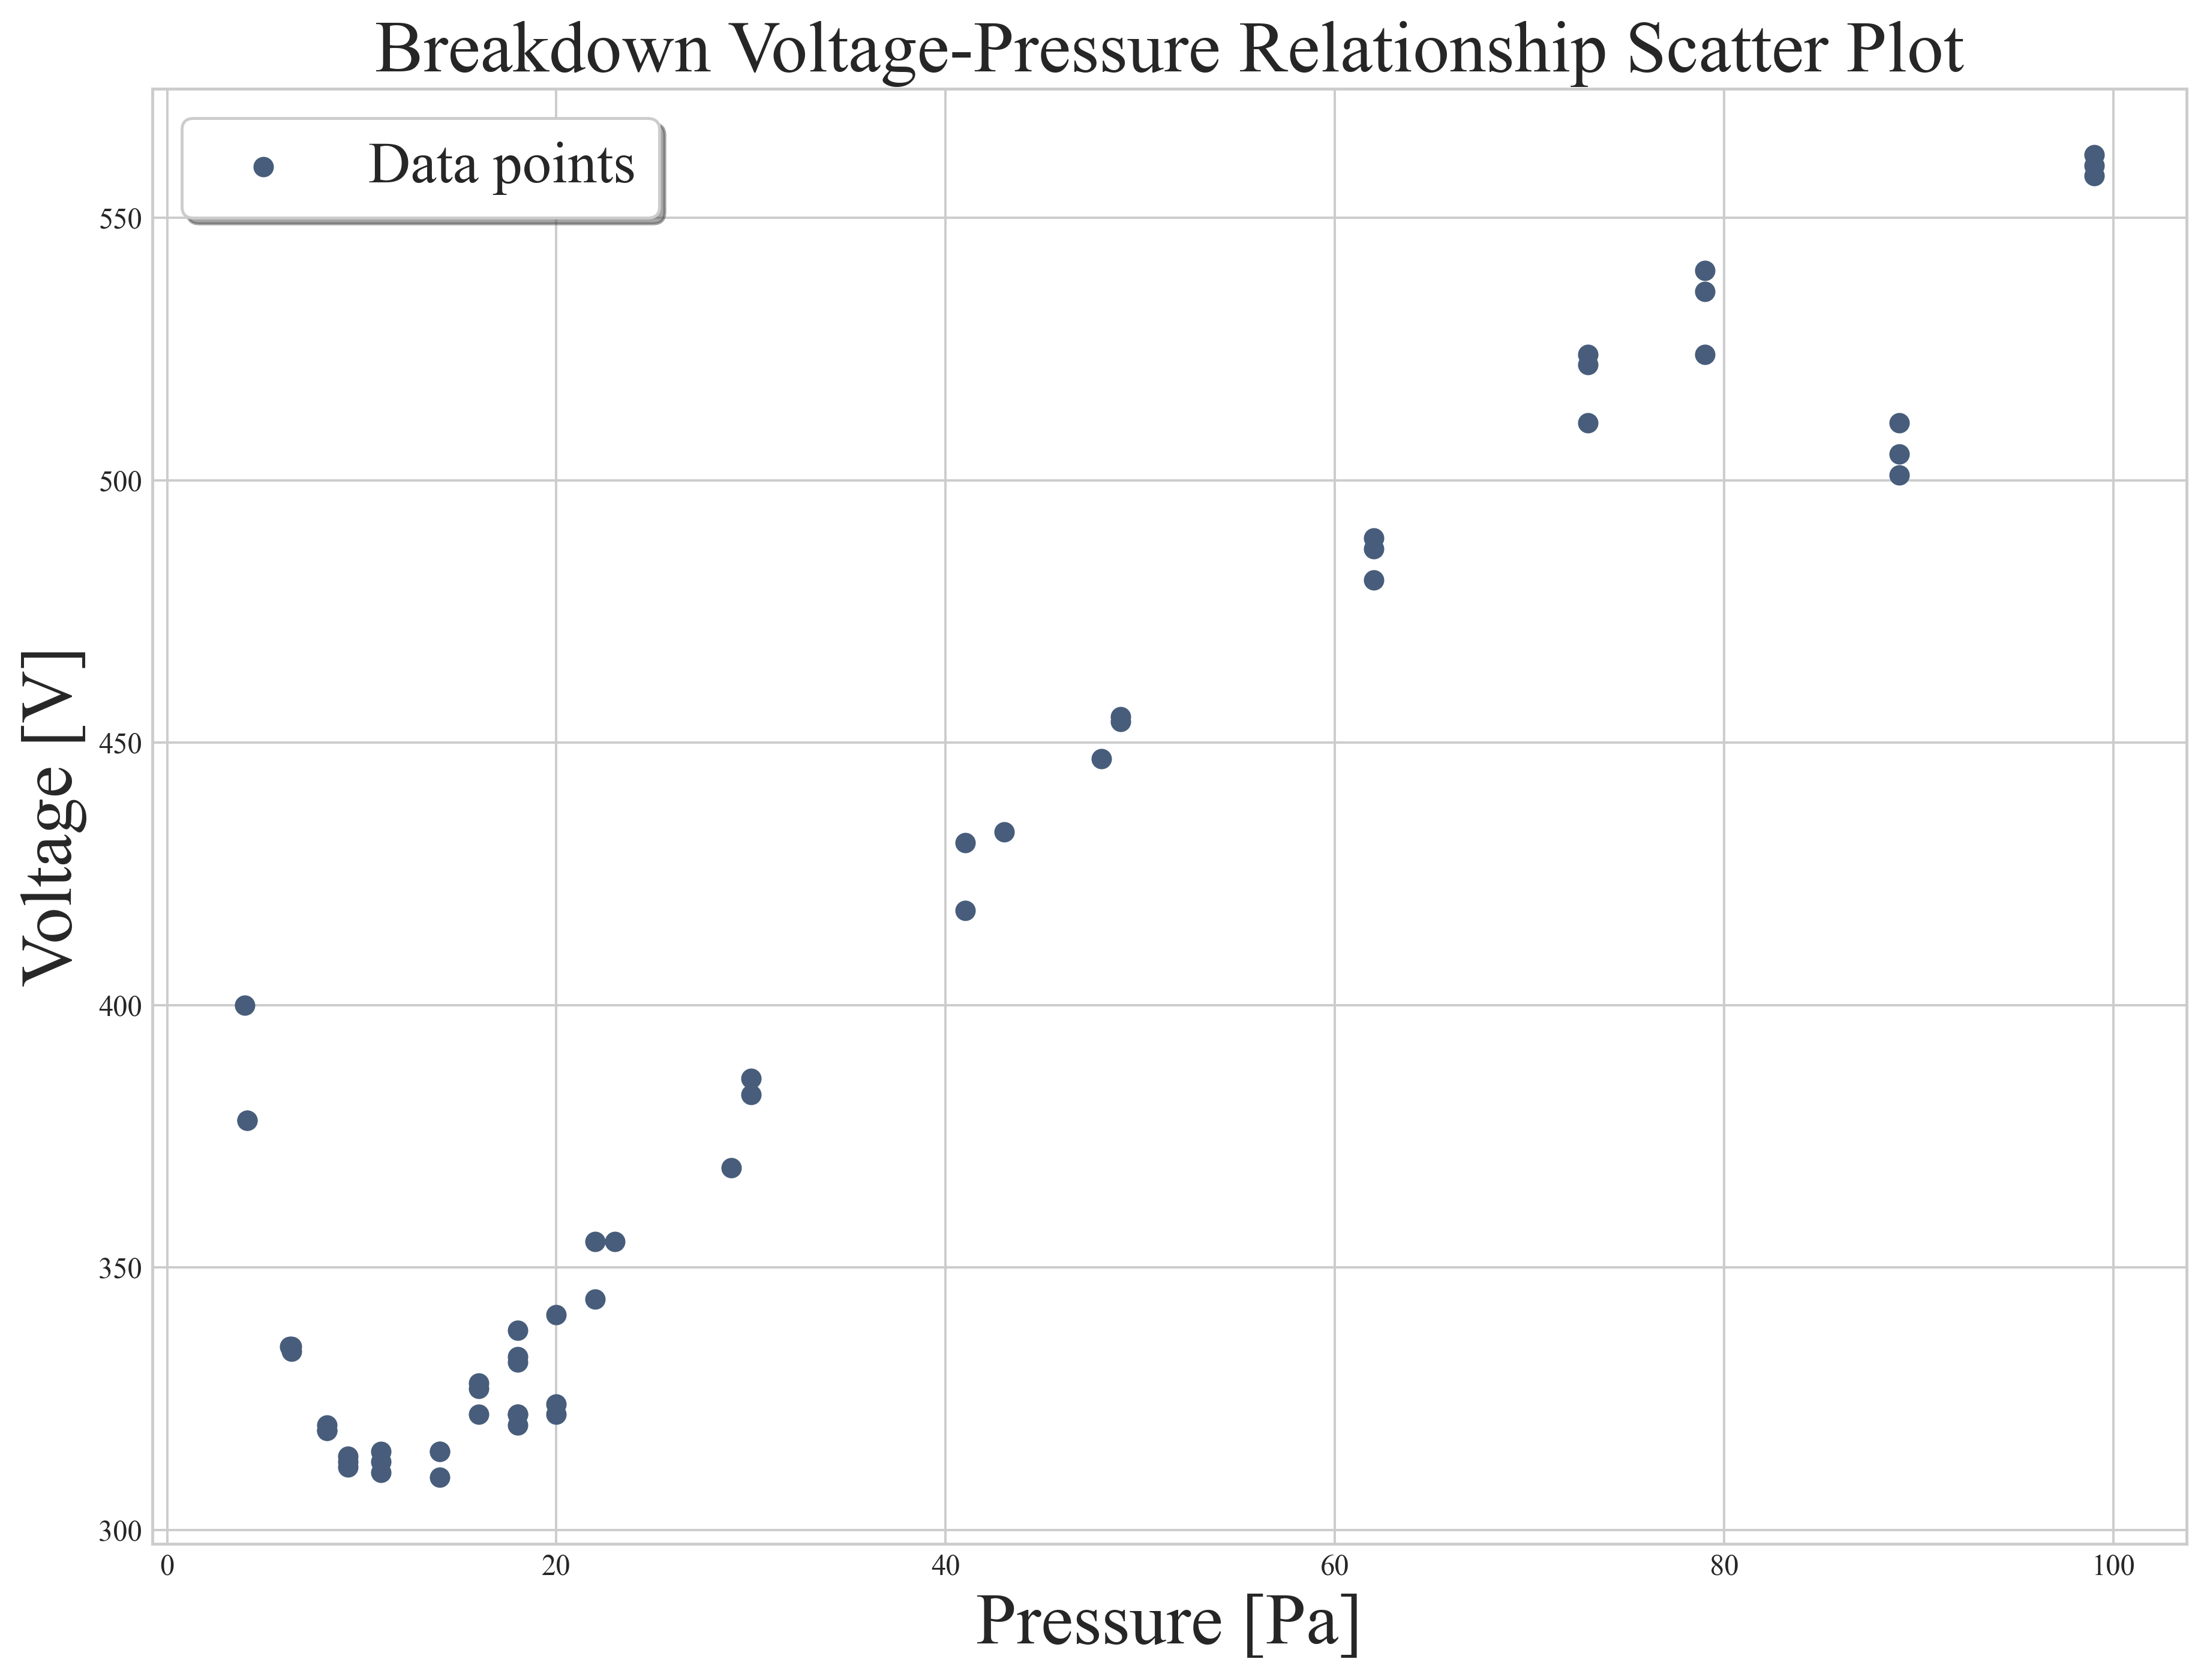

In [ ]:
# 实验二
d = 60 # mm
v2_1 = np.array([320, 322, 322, 386, 383, 369, 418, 433, 431, 447, 454, 455, 481, 487, 489, 511, 522, 524, 524, 540, 536, 511, 501, 505, 558, 560, 562, 355, 344, 355, 324, 322, 341, 338, 333, 332, 322, 328, 327, 315, 315, 310, 313, 311, 315, 312, 314, 313, 319, 320, 319, 335, 335, 334, 400, 378, 378])
p2_1 = np.array([18, 18, 18, 30, 30, 29, 41, 43, 41, 48, 49, 49, 62, 62, 62, 73, 73, 73, 79, 79, 79, 89, 89, 89, 99, 99, 99, 23, 22, 22, 20, 20, 20, 18, 18, 18, 16, 16, 16, 14, 14, 14, 11, 11, 11, 9.3, 9.3, 9.3, 8.2, 8.2, 8.2, 6.3, 6.4, 6.4, 4.0, 4.1, 4.1])
# 将数组按每3个元素分组并计算平均值
v2_1_re = v2_1.reshape(-1, 3)  # 重塑为 (n//3, 3) 的二维数组
v2_1_new = v2_1_re.mean(axis=1)  # 按行计算平均值
p2_1_re = p2_1.reshape(-1, 3)  # 重塑为 (n//3, 3) 的二维数组
p2_1_new = p2_1_re.mean(axis=1)  # 按行计算平均值
yp.std_plot(p2_1, v2_1, 'Data points', plot_type='scatter', plot_name='Breakdown Voltage-Pressure Relationship Scatter Plot', x_label='Pressure [Pa]', y_label='Voltage [V]')

In [24]:
# 定义拟合函数 y = A * x / ln(B * x)
def fitting_func(x, A, B):
    return A * x / np.log(B * x)

# 数据
x_data = p2_1
y_data = v2_1

# 拟合
initial_guess = [1.0, 200.0]  # 初始猜测的参数 A 和 B
popt, pcov = curve_fit(fitting_func, x_data, y_data, p0=initial_guess, maxfev=10000)

# 获取拟合参数 A 和 B
A, B = popt
print(f"拟合参数: A = {A:.4f}, B = {B:.4f}")

# 计算拟合曲线上的 y 最小值
# 在拟合曲线的范围内寻找最小值
x_fit = np.linspace(min(x_data), max(x_data), 1000)
y_fit = fitting_func(x_fit, A, B)
y_min = y_fit.min()
x_at_y_min = x_fit[np.argmin(y_fit)]
print(f"y 最小值: {y_min:.4f}，对应的 x 值: {x_at_y_min:.4f}")


拟合参数: A = 23.6453, B = 0.3057
y 最小值: 210.2543，对应的 x 值: 8.8498


/var/folders/7l/1kcst3m15b3f1jyrwvsyrckw0000gn/T/ipykernel_52393/47706734.py:3: RuntimeWarning: invalid value encountered in log
  return A * x / np.log(B * x)


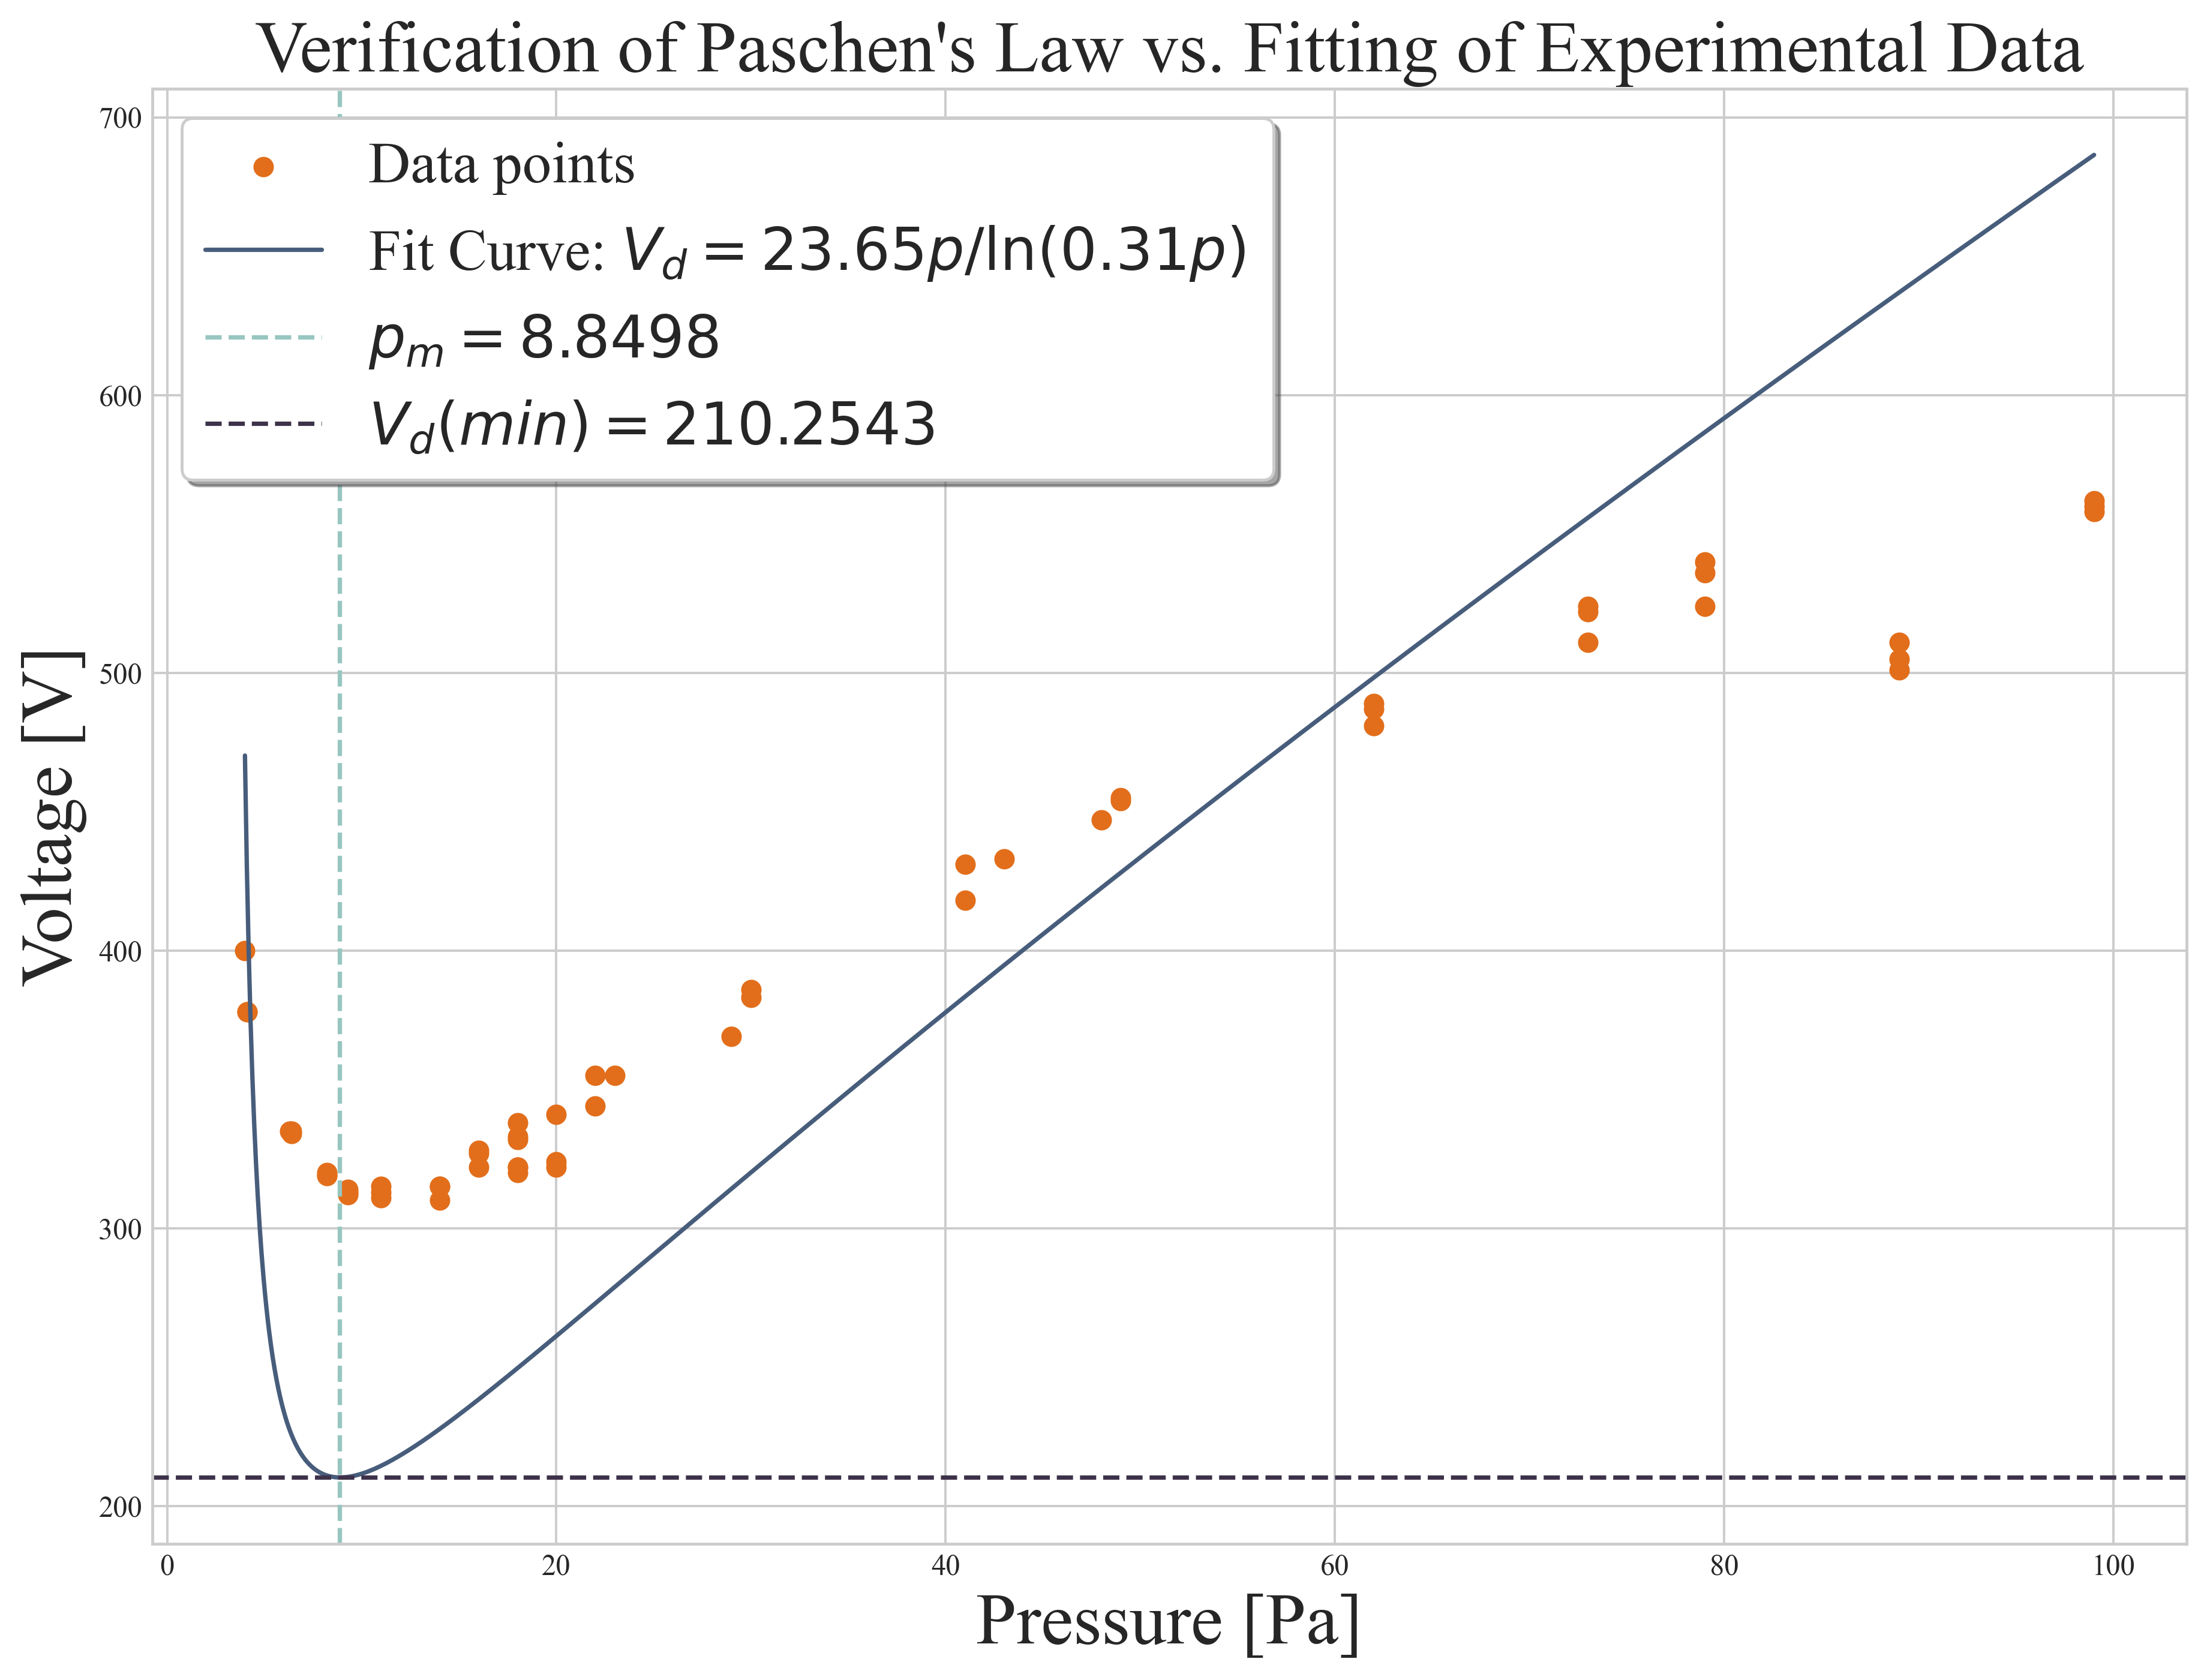

In [25]:
# 可视化
plt.scatter(x_data, y_data, label="Data points", color=yp.firefly()[3])
plt.plot(x_fit, y_fit, label=f"Fit Curve: $V_d = {A:.2f}p / \ln({B:.2f}p)$ ", color=yp.firefly()[1])
plt.axvline(x=x_at_y_min, color=yp.firefly()[2], linestyle="--", label=f"$p_m = {x_at_y_min:.4f}$")
plt.axhline(y=y_min, color=yp.firefly()[0], linestyle="--", label=f"$V_d(min) = {y_min:.4f}$")
plt.legend(fontsize=20, frameon=True, shadow=True)
plt.xlabel("Pressure [Pa]")
plt.ylabel("Voltage [V]")
plt.title("Verification of Paschen's Law vs. Fitting of Experimental Data", fontsize=25)
plt.show()

In [27]:
# 拟合效果评定
error2 = 0
for i in range(len(p2_1)):
    x = p2_1[i]
    y_original = v2_1[i]
    y_fit = fitting_func(x, A, B)
    error2 = error2 + (y_fit - y_original)**2
error2 = error2 / (len(p2_1) * np.mean(v2_1))
error2

17.16621315985749

In [51]:
# 实验三
data3_Ar = np.loadtxt('Ar_1.txt')
data3_ref2 = np.loadtxt('ref2.txt')
i_Ar = data3_Ar[:, 1] - data3_ref2[:, 1]
l_Ar = data3_Ar[:, 0]

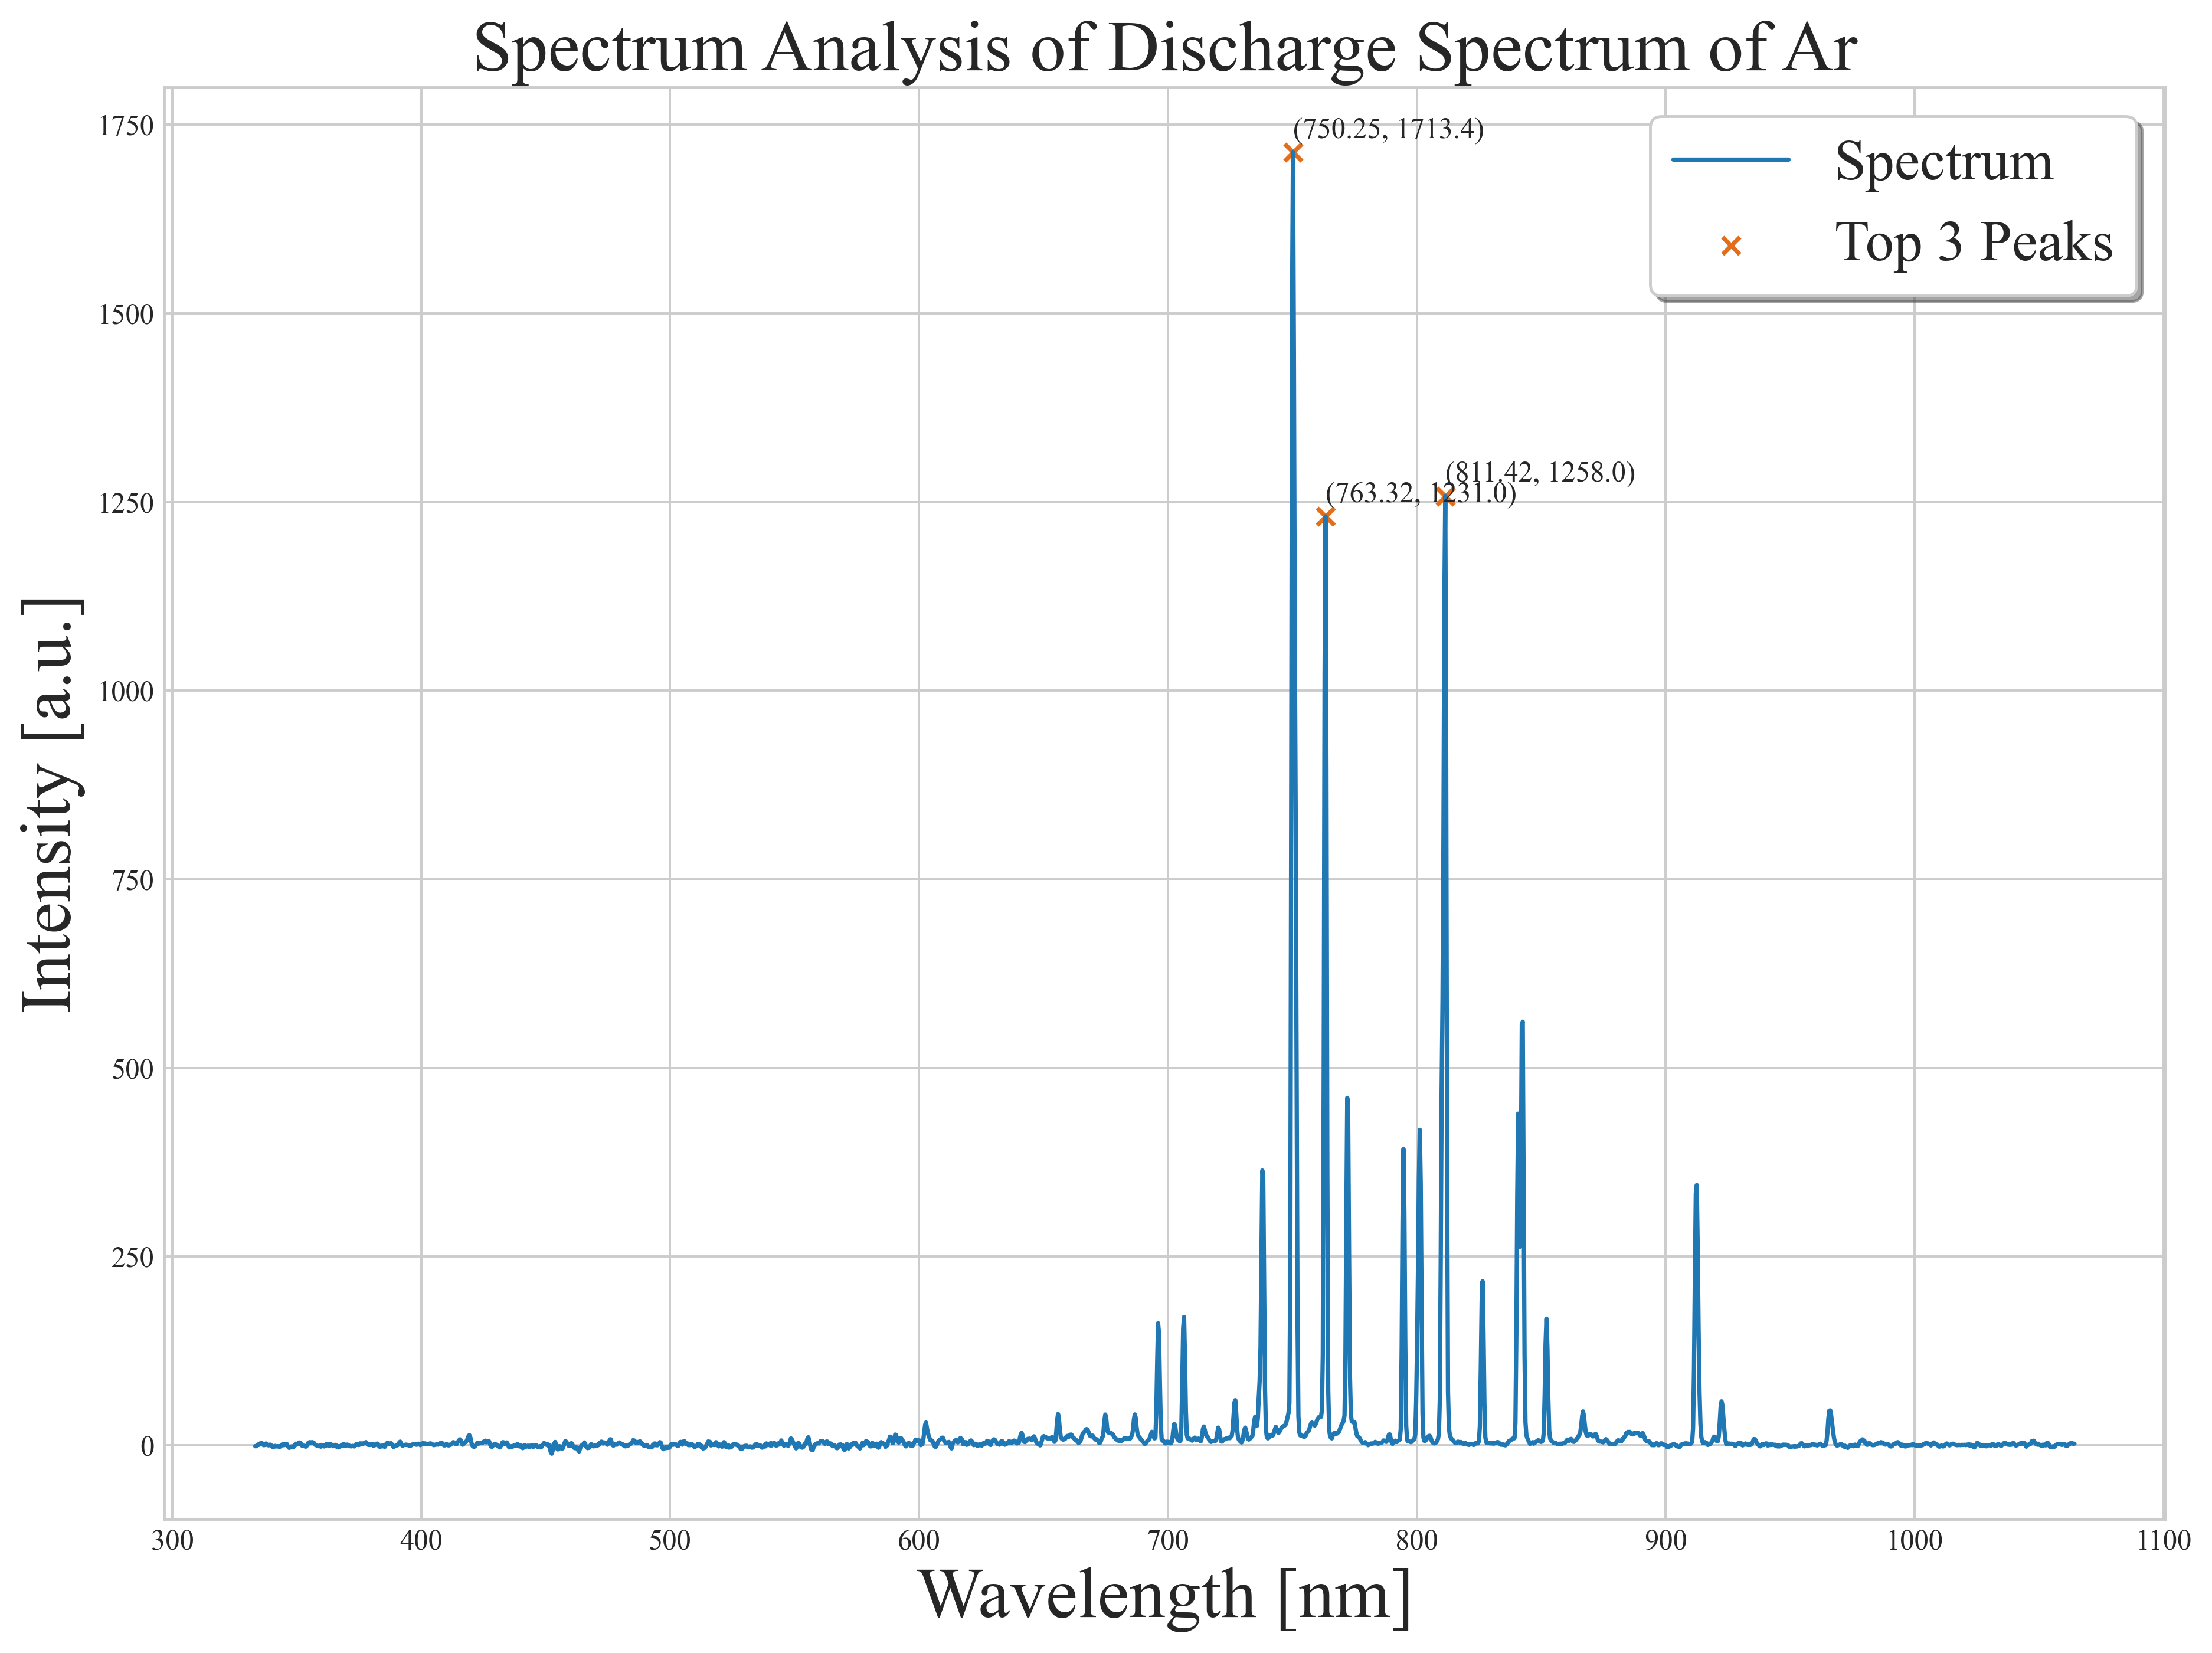

In [52]:
# 数据加载
wavelength = l_Ar
intensity = i_Ar

# 设置阈值，`height` 控制峰值最低高度，`prominence` 控制突出程度
peaks, properties = find_peaks(intensity, height=0.1, prominence=0.05)

# 根据强度排序，选择强度最高的 3 个峰
sorted_indices = np.argsort(properties['peak_heights'])[-3:]  # 最后3个最高峰的索引
main_peaks = peaks[sorted_indices]  # 对应的峰位置

# 绘制光谱图及标注峰值位置
plt.figure()
plt.plot(wavelength, intensity, label="Spectrum")
plt.scatter(wavelength[main_peaks], intensity[main_peaks], color=yp.firefly()[3], label="Top 3 Peaks", marker='x')
# 标注前三强度的峰的波长
for peak in main_peaks:
    plt.annotate('({}, {})'.format(round(wavelength[peak], 2), round(intensity[peak], 2)), xy=(wavelength[peak], intensity[peak]),
                 xytext=(0, 5), textcoords='offset points')  
plt.xlabel("Wavelength [nm]")
plt.ylabel("Intensity [a.u.]")
plt.title("Spectrum Analysis of Discharge Spectrum of Ar", fontsize=25)
plt.legend(fontsize=20, frameon=True, shadow=True)
plt.show()

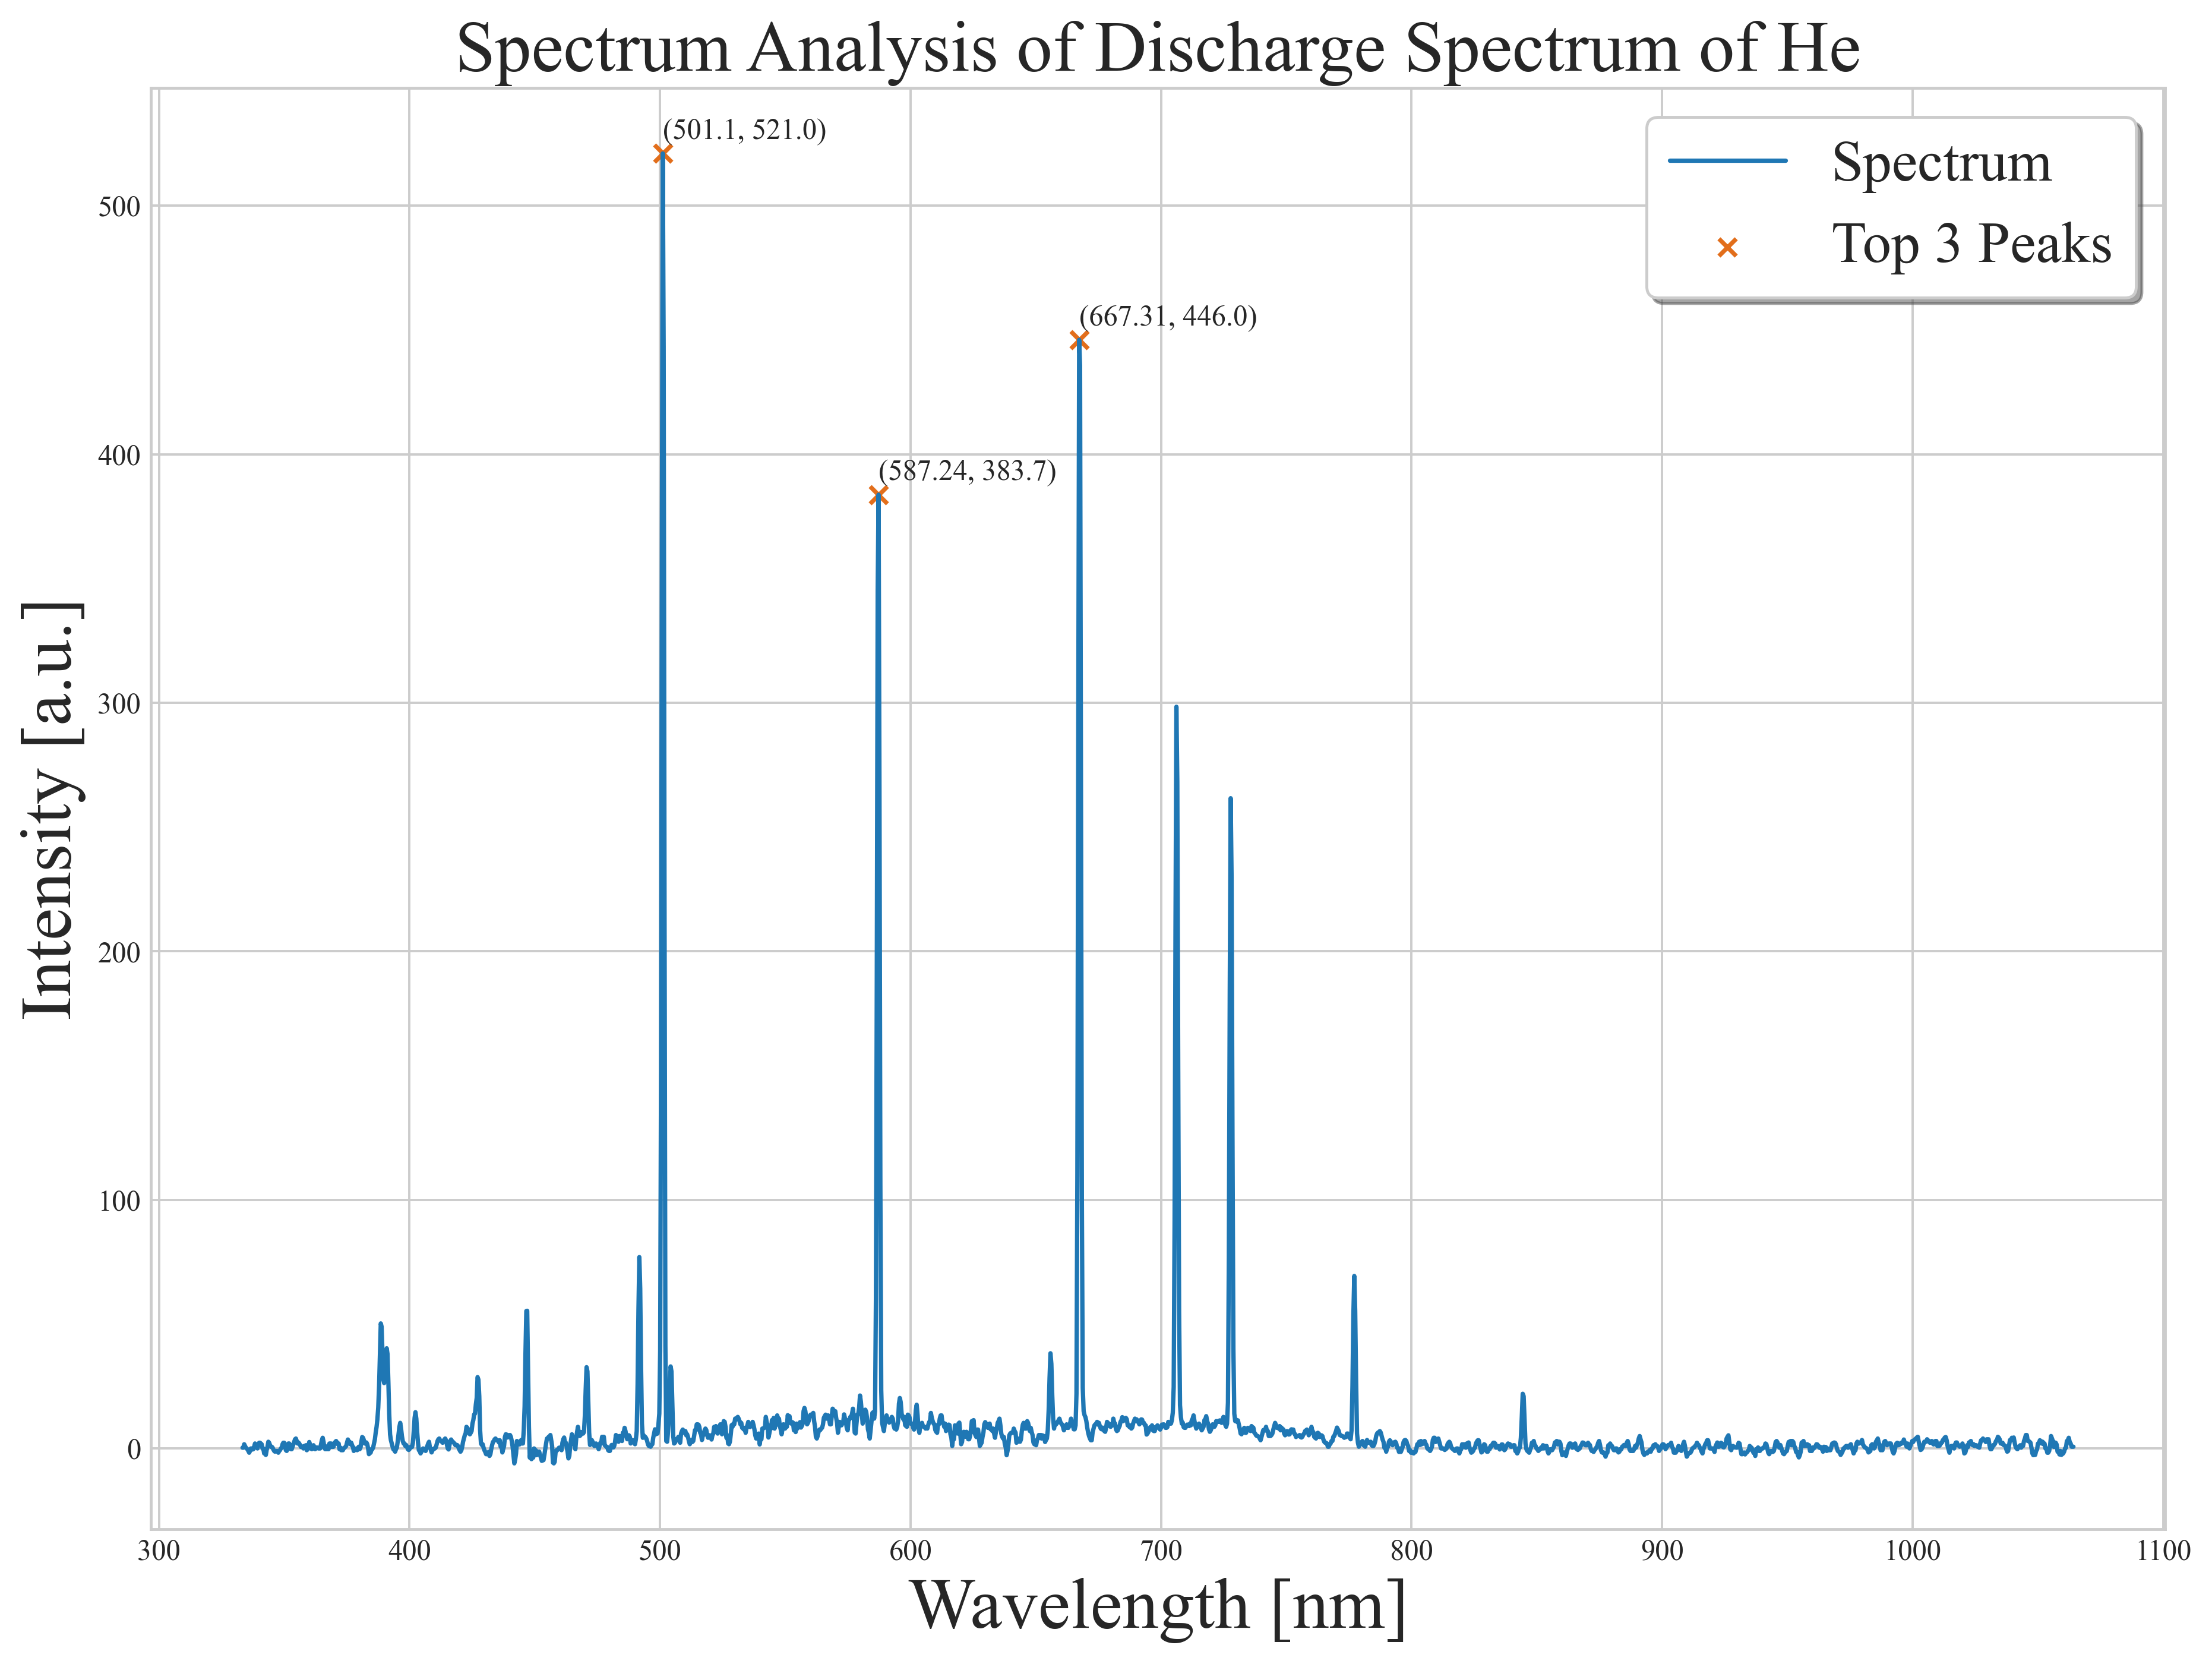

In [65]:
data3_He = np.loadtxt('He_1.txt')
data3_ref1 = np.loadtxt('ref1.txt')
i_He = data3_He[:, 1] - data3_ref1[:, 1]
l_He = data3_He[:, 0]

# 数据加载
wavelength = l_He
intensity = i_He

# 设置阈值，`height` 控制峰值最低高度，`prominence` 控制突出程度
peaks, properties = find_peaks(intensity, height=0.1, prominence=0.05)

# 根据强度排序，选择强度最高的 3 个峰
sorted_indices = np.argsort(properties['peak_heights'])[-3:]  # 最后3个最高峰的索引
main_peaks = peaks[sorted_indices]  # 对应的峰位置

# 绘制光谱图及标注峰值位置
plt.figure()
plt.plot(wavelength, intensity, label="Spectrum")
plt.scatter(wavelength[main_peaks], intensity[main_peaks], color=yp.firefly()[3], label="Top 3 Peaks", marker='x')
# 标注前三强度的峰的波长
for peak in main_peaks:
    plt.annotate('({}, {})'.format(round(wavelength[peak], 2), round(intensity[peak], 2)), xy=(wavelength[peak], intensity[peak]),
                 xytext=(0, 5), textcoords='offset points')  
plt.xlabel("Wavelength [nm]")
plt.ylabel("Intensity [a.u.]")
plt.title("Spectrum Analysis of Discharge Spectrum of He", fontsize=25)
plt.legend(fontsize=20, frameon=True, shadow=True)
plt.show()

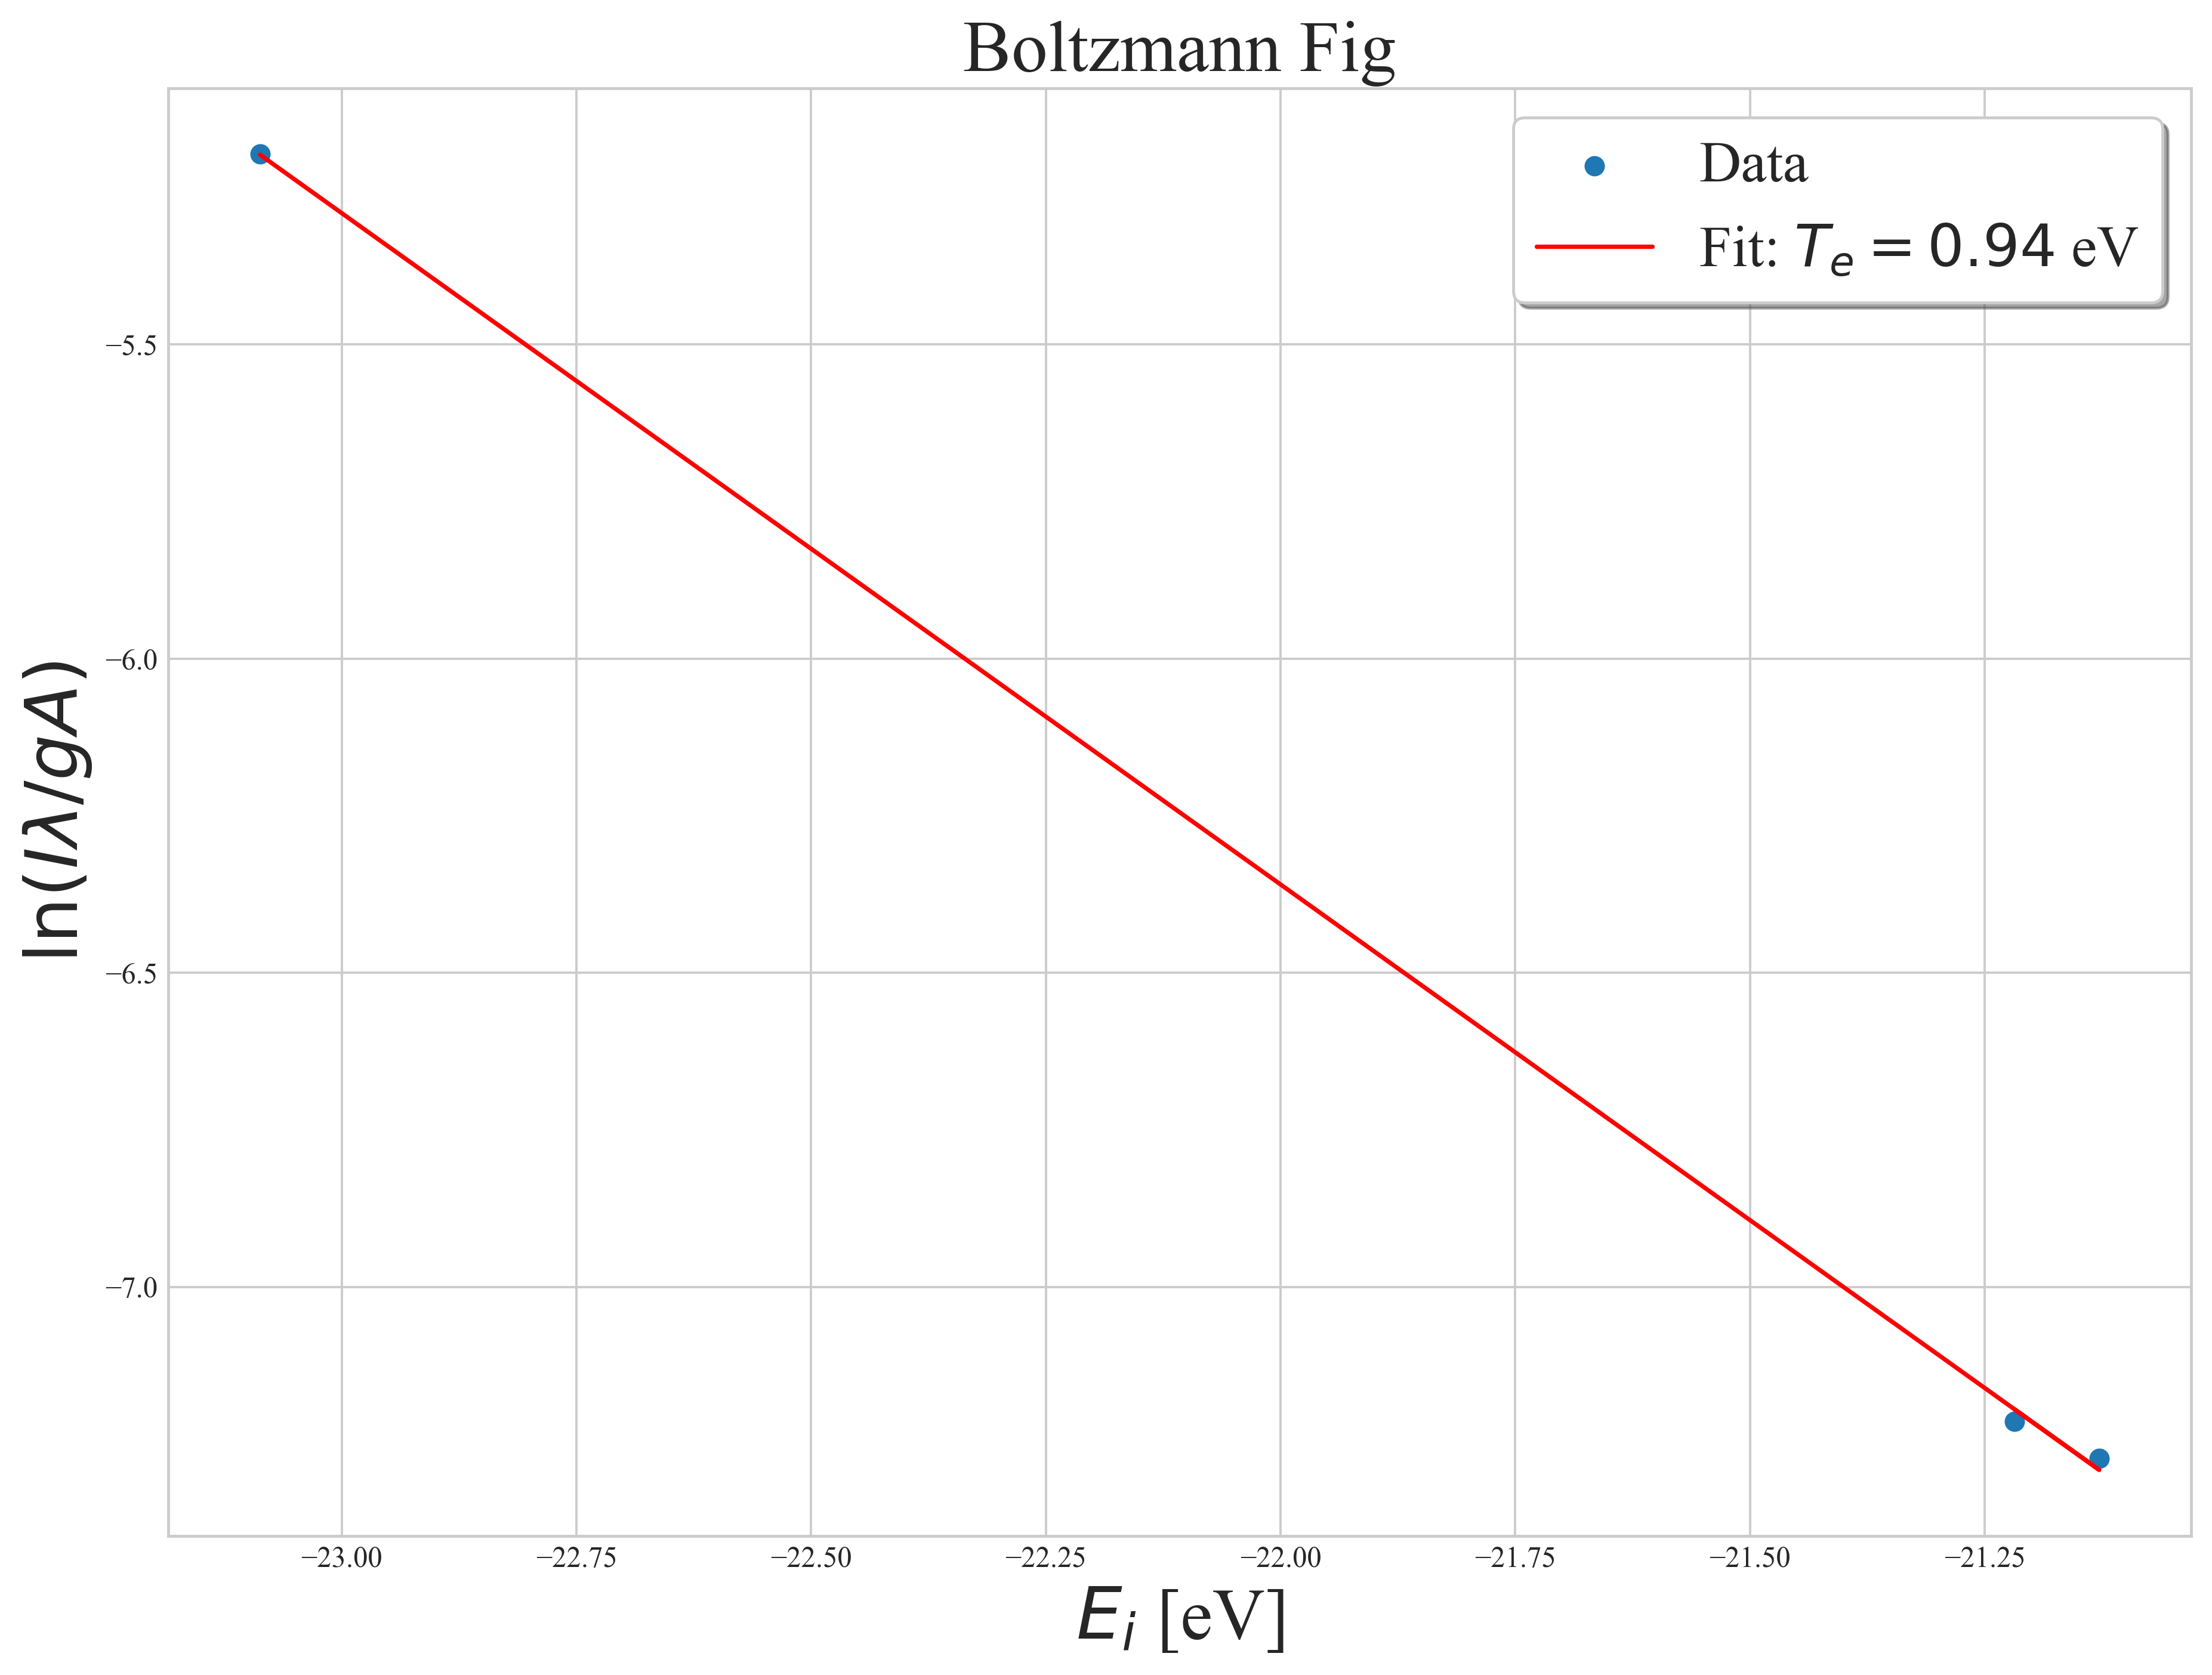

电子温度 (T_e): 0.94 eV


In [60]:
# 利用谱线特征获得等离子体参数

import numpy as np
import matplotlib.pyplot as plt

# Input data: wavelength, intensity, energy levels, degeneracies, and Einstein A coefficients
wavelengths = np.array([587.244, 667.311, 501.099])  # nm
intensities = np.array([383.7, 446.0, 521.0])        # Arbitrary units
energy_levels = -np.array([21.218, 21.128, 23.087])  # eV
degeneracies = np.array([3, 5, 1])                  # Statistical weights
a_coefficients = np.array([1.02e8, 8.58e7, 4.72e7]) # Einstein A coefficients (1/s)

# Boltzmann plot method
def boltzmann_plot(wavelengths, intensities, energy_levels, degeneracies, a_coefficients):
    """
    Calculate electron temperature using Boltzmann plot.
    """
    # Calculate x (energy levels) and y (logarithmic terms for Boltzmann plot)
    x = energy_levels
    y = np.log(intensities * wavelengths / (degeneracies * a_coefficients))
    
    # Perform linear fit
    slope, intercept = np.polyfit(x, y, 1)
    T_e = -1 / slope  # T_e in eV

    # 绘制 Boltzmann 图
    plt.figure()
    plt.scatter(x, y, label="Data")
    plt.plot(x, slope * x + intercept, color="red", label=f"Fit: $T_e = {T_e:.2f}$ eV")
    plt.xlabel("$E_i$ [eV]")
    plt.ylabel("$\\ln(I \\lambda / g A)$")
    plt.title("Boltzmann Fig", fontsize=25)
    plt.legend(fontsize=20, frameon=True, shadow=True)
    plt.show()

    return T_e

# 计算电子温度
T_e = boltzmann_plot(wavelengths, intensities, energy_levels, degeneracies, a_coefficients)
print(f"电子温度 (T_e): {T_e:.2f} eV")

In [61]:
# 主峰寻峰与计算半高宽
x = l_He
y = i_He

# 找到主峰
peaks, _ = find_peaks(y)
peak_index = peaks[np.argmax(y[peaks])]  # 主峰索引
peak_x = x[peak_index]  # 主峰位置
peak_y = y[peak_index]  # 主峰值

# 半高宽计算* （注意它给出了一个处理离散实验数据的非拟合方案的标准半高宽计算流程）
half_max = peak_y / 2
left_idx = np.where(y[:peak_index] <= half_max)[0][-1]
right_idx = np.where(y[peak_index:] <= half_max)[0][0] + peak_index
# 线性插值计算左右边界的精确位置*
x_left = x[left_idx] + (half_max - y[left_idx]) / (y[left_idx + 1] - y[left_idx]) * (x[left_idx + 1] - x[left_idx])
x_right = x[right_idx] + (half_max - y[right_idx]) / (y[right_idx - 1] - y[right_idx]) * (x[right_idx - 1] - x[right_idx])
# 半高宽
fwhm = x_right - x_left

# 输出结果
print(f"主峰位置: {peak_x:.4f}")
print(f"主峰值: {peak_y:.4f}")
print(f"半高宽 (FWHM): {fwhm:.4f}")

主峰位置: 501.0990
主峰值: 521.0000
半高宽 (FWHM): 1.1545


In [62]:
def calculate_electron_density(delta_lambda_stark, w_parameter):
    """
    Calculate electron density (n_e) using Stark broadening.
    Parameters:
        delta_lambda_stark: Stark broadening FWHM (nm)
        w_parameter: Stark broadening parameter (nm * cm^3)
    Returns:
        n_e: Electron density (cm^-3)
    """
    n_e = (delta_lambda_stark / (2 * w_parameter)) ** (3 / 2)
    return n_e

# Given data
delta_lambda_stark = 1.1545  # Measured FWHM (nm)
w_parameter = 0.05           # Stark broadening parameter (nm * cm^3)

# Calculate electron density
n_e = calculate_electron_density(delta_lambda_stark, w_parameter)
print(f"Electron Density (n_e): {n_e:.2e} cm^-3")


Electron Density (n_e): 3.92e+01 cm^-3


In [63]:
# Constants
m_e = 9.109e-31  # Electron mass (kg)
k_B = 8.617e-5   # Boltzmann constant (eV/K)
h = 4.135e-15    # Planck constant (eV·s)

def saha_equation(T_e, n_e, Z_i, Z_i1, E_ion):
    """
    Calculate the ratio of n_{i+1} / n_i using the Saha equation.
    Parameters:
        T_e: Electron temperature (eV)
        n_e: Electron density (cm^-3)
        Z_i: Partition function of the current ionization state
        Z_i1: Partition function of the next ionization state
        E_ion: Ionization energy (eV)
    Returns:
        n_i_ratio: Ratio of n_{i+1} / n_i
    """
    # Convert n_e to SI units (m^-3)
    n_e_si = n_e * 1e6  # cm^-3 to m^-3

    # Saha equation constant
    saha_const = (2 * np.pi * m_e * k_B * T_e / h**2)**(3/2)
    saha_const *= (2 * Z_i1) / Z_i
    exp_term = np.exp(-E_ion / T_e)
    n_i_ratio = saha_const * exp_term / n_e_si

    return n_i_ratio

# Given data
# Electron temperature (eV)
# Electron density (cm^-3)
Z_i = 1.0   # Partition function of neutral He
Z_i1 = 2.0  # Partition function of singly ionized He
E_ion = 24.58  # Ionization energy of He (eV)

# Calculate the ratio n_{i+1} / n_i
n_i_ratio = saha_equation(T_e, n_e, Z_i, Z_i1, E_ion)
print(f"n_{i+1} / n_i: {n_i_ratio:.2e}")

# Example: Total particle density
n_total = 1e19  # Total particle density (cm^-3) (arbitrary example)
n_i = n_total / (1 + n_i_ratio)
n_i1 = n_total - n_i

print(f"Ion Density (n_i): {n_i:.2e} cm^-3")
print(f"Ion Density (n_{i+1}): {n_i1:.2e} cm^-3")


n_40 / n_i: 5.62e-26
Ion Density (n_i): 1.00e+19 cm^-3
Ion Density (n_40): 0.00e+00 cm^-3


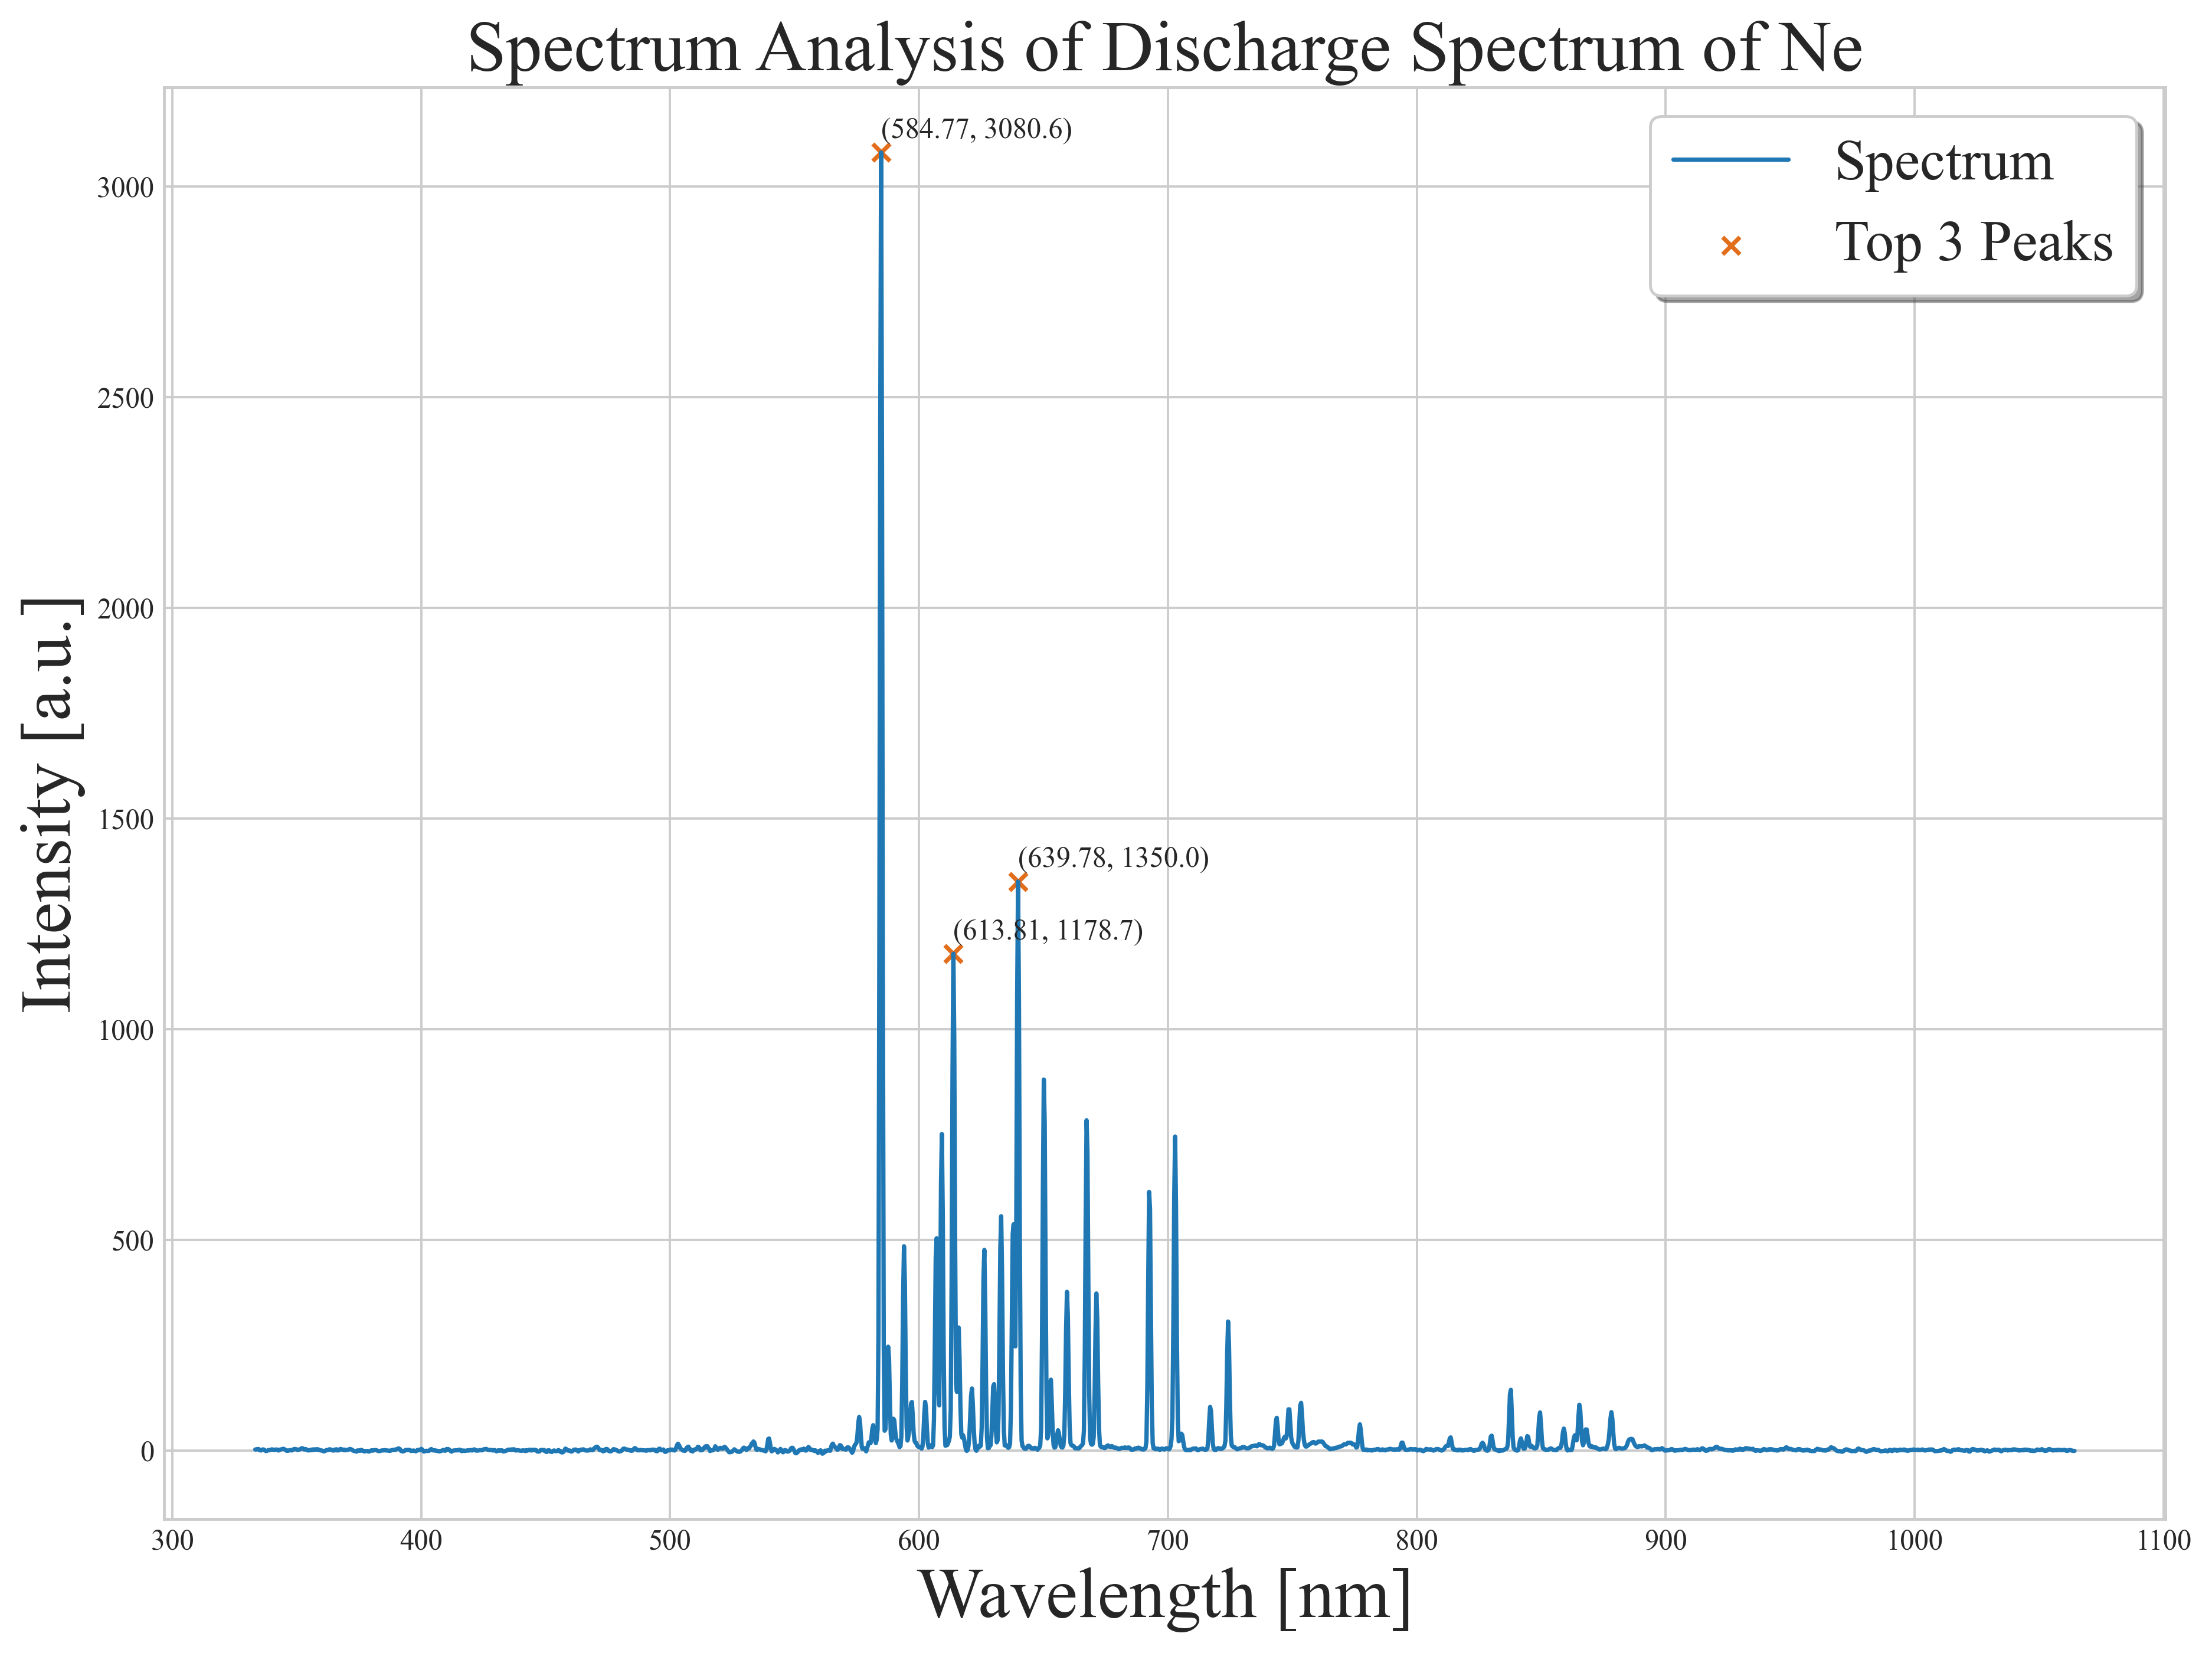

In [64]:
data3_Ne = np.loadtxt('Ne_1.txt')
data3_ref3 = np.loadtxt('ref3.txt')
i_Ne = data3_Ne[:, 1] - data3_ref3[:, 1]
l_Ne = data3_Ne[:, 0]

# 数据加载
wavelength = l_Ne
intensity = i_Ne

# 设置阈值，`height` 控制峰值最低高度，`prominence` 控制突出程度
peaks, properties = find_peaks(intensity, height=0.1, prominence=0.05)

# 根据强度排序，选择强度最高的 3 个峰
sorted_indices = np.argsort(properties['peak_heights'])[-3:]  # 最后3个最高峰的索引
main_peaks = peaks[sorted_indices]  # 对应的峰位置

# 绘制光谱图及标注峰值位置
plt.figure()
plt.plot(wavelength, intensity, label="Spectrum")
plt.scatter(wavelength[main_peaks], intensity[main_peaks], color=yp.firefly()[3], label="Top 3 Peaks", marker='x')
# 标注前三强度的峰的波长
for peak in main_peaks:
    plt.annotate('({}, {})'.format(round(wavelength[peak], 2), round(intensity[peak], 2)), xy=(wavelength[peak], intensity[peak]),
                 xytext=(0, 5), textcoords='offset points')  
plt.xlabel("Wavelength [nm]")
plt.ylabel("Intensity [a.u.]")
plt.title("Spectrum Analysis of Discharge Spectrum of Ne", fontsize=25)
plt.legend(fontsize=20, frameon=True, shadow=True)
plt.show()

In [89]:
# 实验四
data4_air = np.loadtxt('air1.xls', skiprows=6)
mass_air = data4_air[:, 0]
amp_air = data4_air[:, 1]
mass_air = mass_air[:2*len(mass_air)//3]
amp_air = amp_air[:2*len(amp_air)//3]

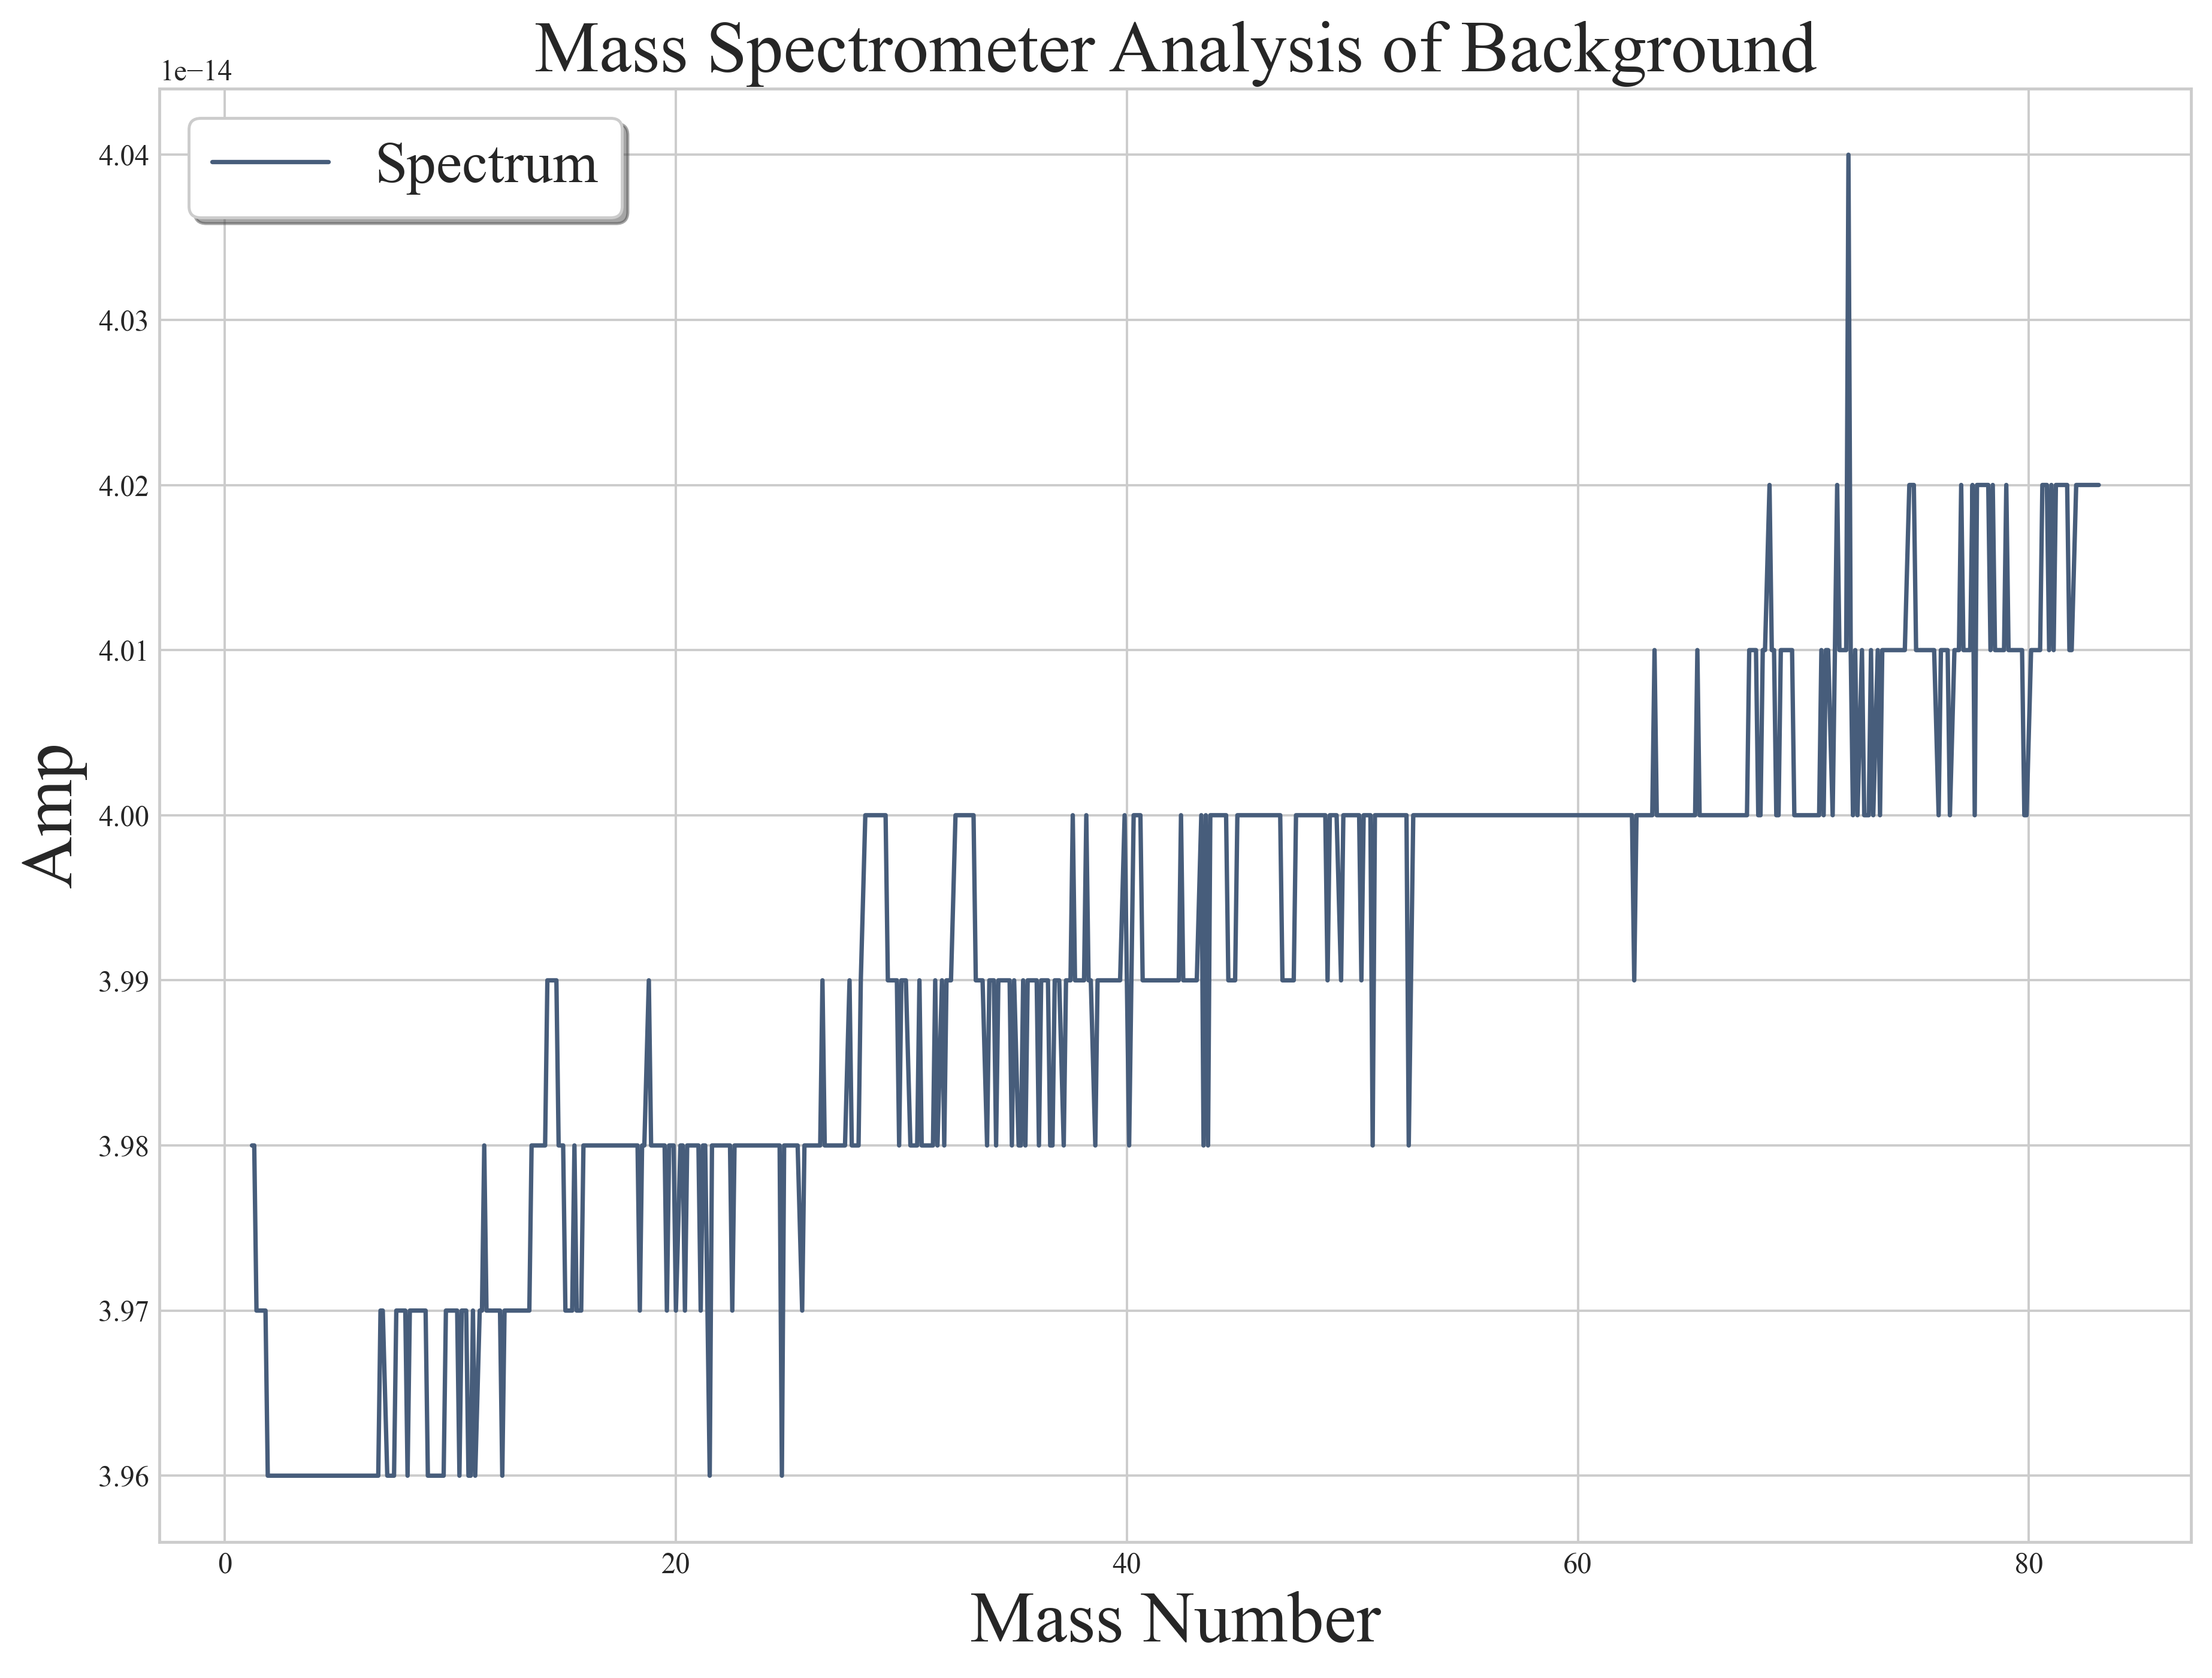

In [90]:
data4_bg = np.loadtxt('backgound1.xls', skiprows=6)
mass_bg = data4_bg[:, 0]
amp_bg = data4_bg[:, 1]
mass_bg = mass_bg[:2*len(mass_bg)//3]
amp_bg = amp_bg[:2*len(amp_bg)//3]
yp.std_plot(mass_bg, amp_bg, 'Spectrum', plot_name='Mass Spectrometer Analysis of Background', x_label='Mass Number', y_label='Amp')

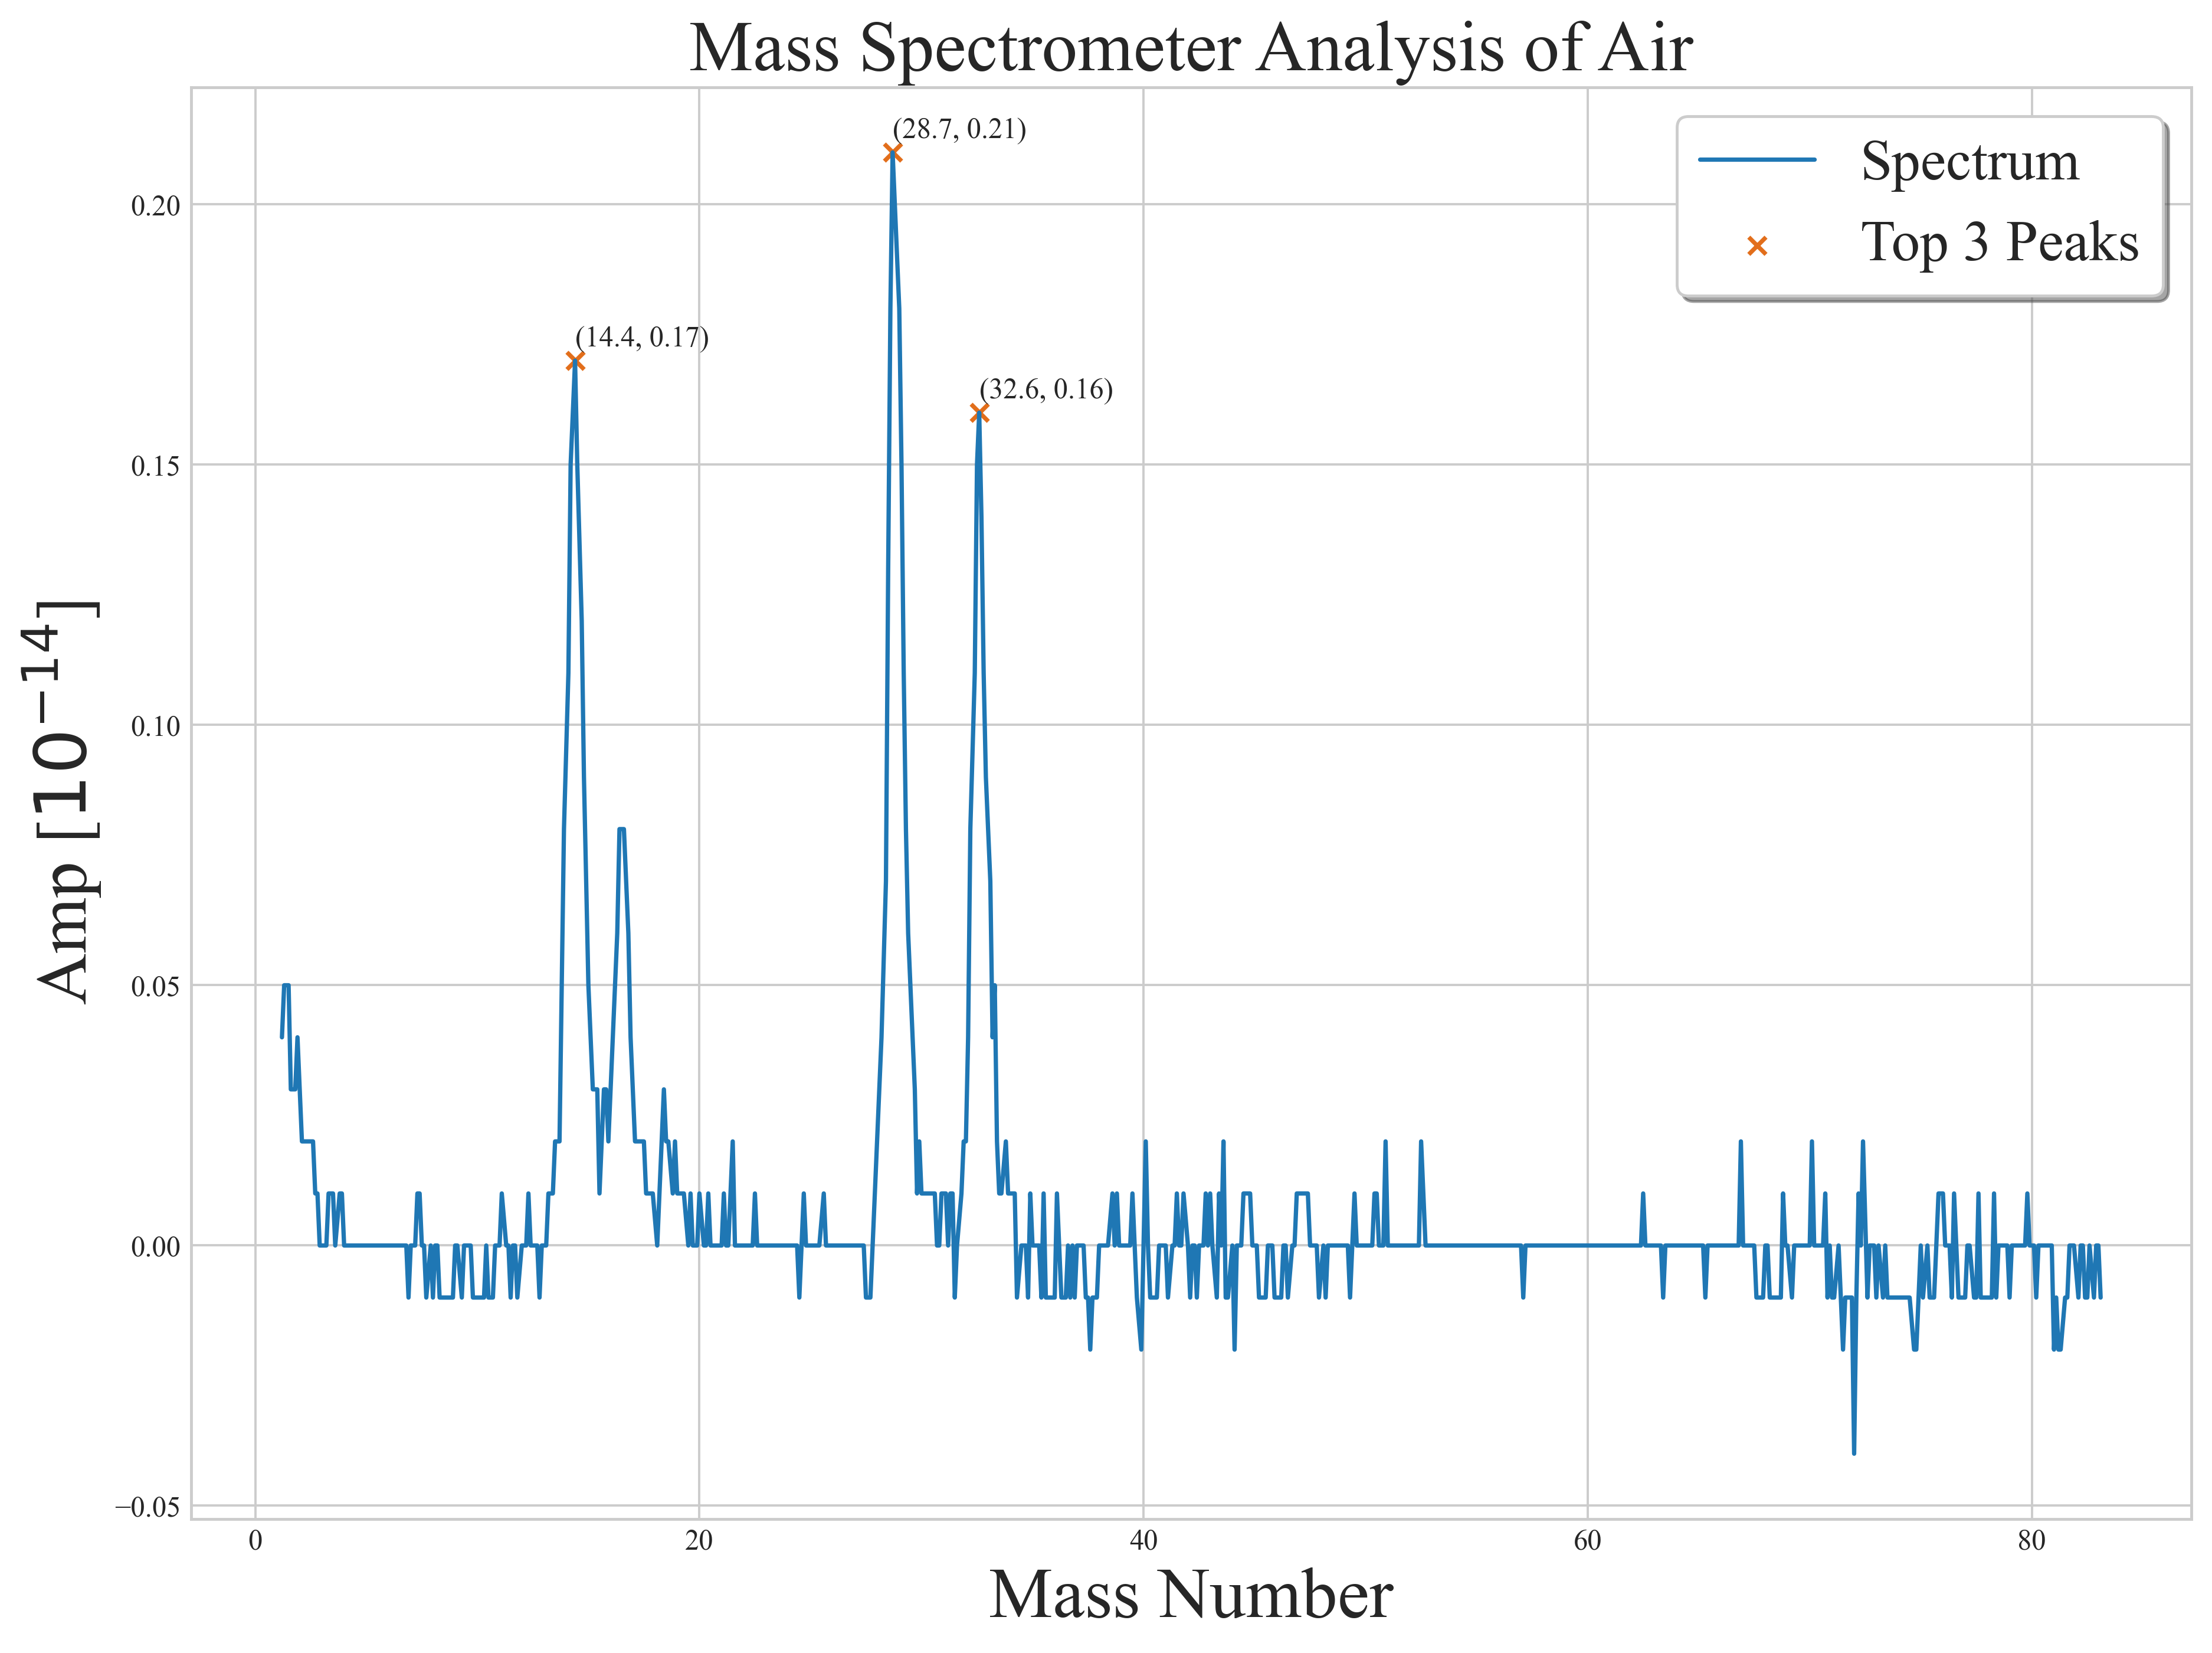

In [91]:
# 数据加载
wavelength = mass_air
intensity = (amp_air - amp_bg)*1e14

# 设置阈值，`height` 控制峰值最低高度，`prominence` 控制突出程度
peaks, properties = find_peaks(intensity, height=0.1, prominence=0.05)

# 根据强度排序，选择强度最高的 3 个峰
sorted_indices = np.argsort(properties['peak_heights'])[-3:]  # 最后3个最高峰的索引
main_peaks = peaks[sorted_indices]  # 对应的峰位置

# 绘制光谱图及标注峰值位置
plt.figure()
plt.plot(wavelength, intensity, label="Spectrum")
plt.scatter(wavelength[main_peaks], intensity[main_peaks], color=yp.firefly()[3], label="Top 3 Peaks", marker='x')
# 标注前三强度的峰的波长
for peak in main_peaks:
    plt.annotate('({}, {})'.format(round(wavelength[peak], 2), round(intensity[peak], 2)), xy=(wavelength[peak], intensity[peak]),
                 xytext=(0, 5), textcoords='offset points')  
plt.xlabel("Mass Number")
plt.ylabel("Amp [$10^{-14}$]")
plt.title("Mass Spectrometer Analysis of Air", fontsize=25)
plt.legend(fontsize=20, frameon=True, shadow=True)
plt.show()

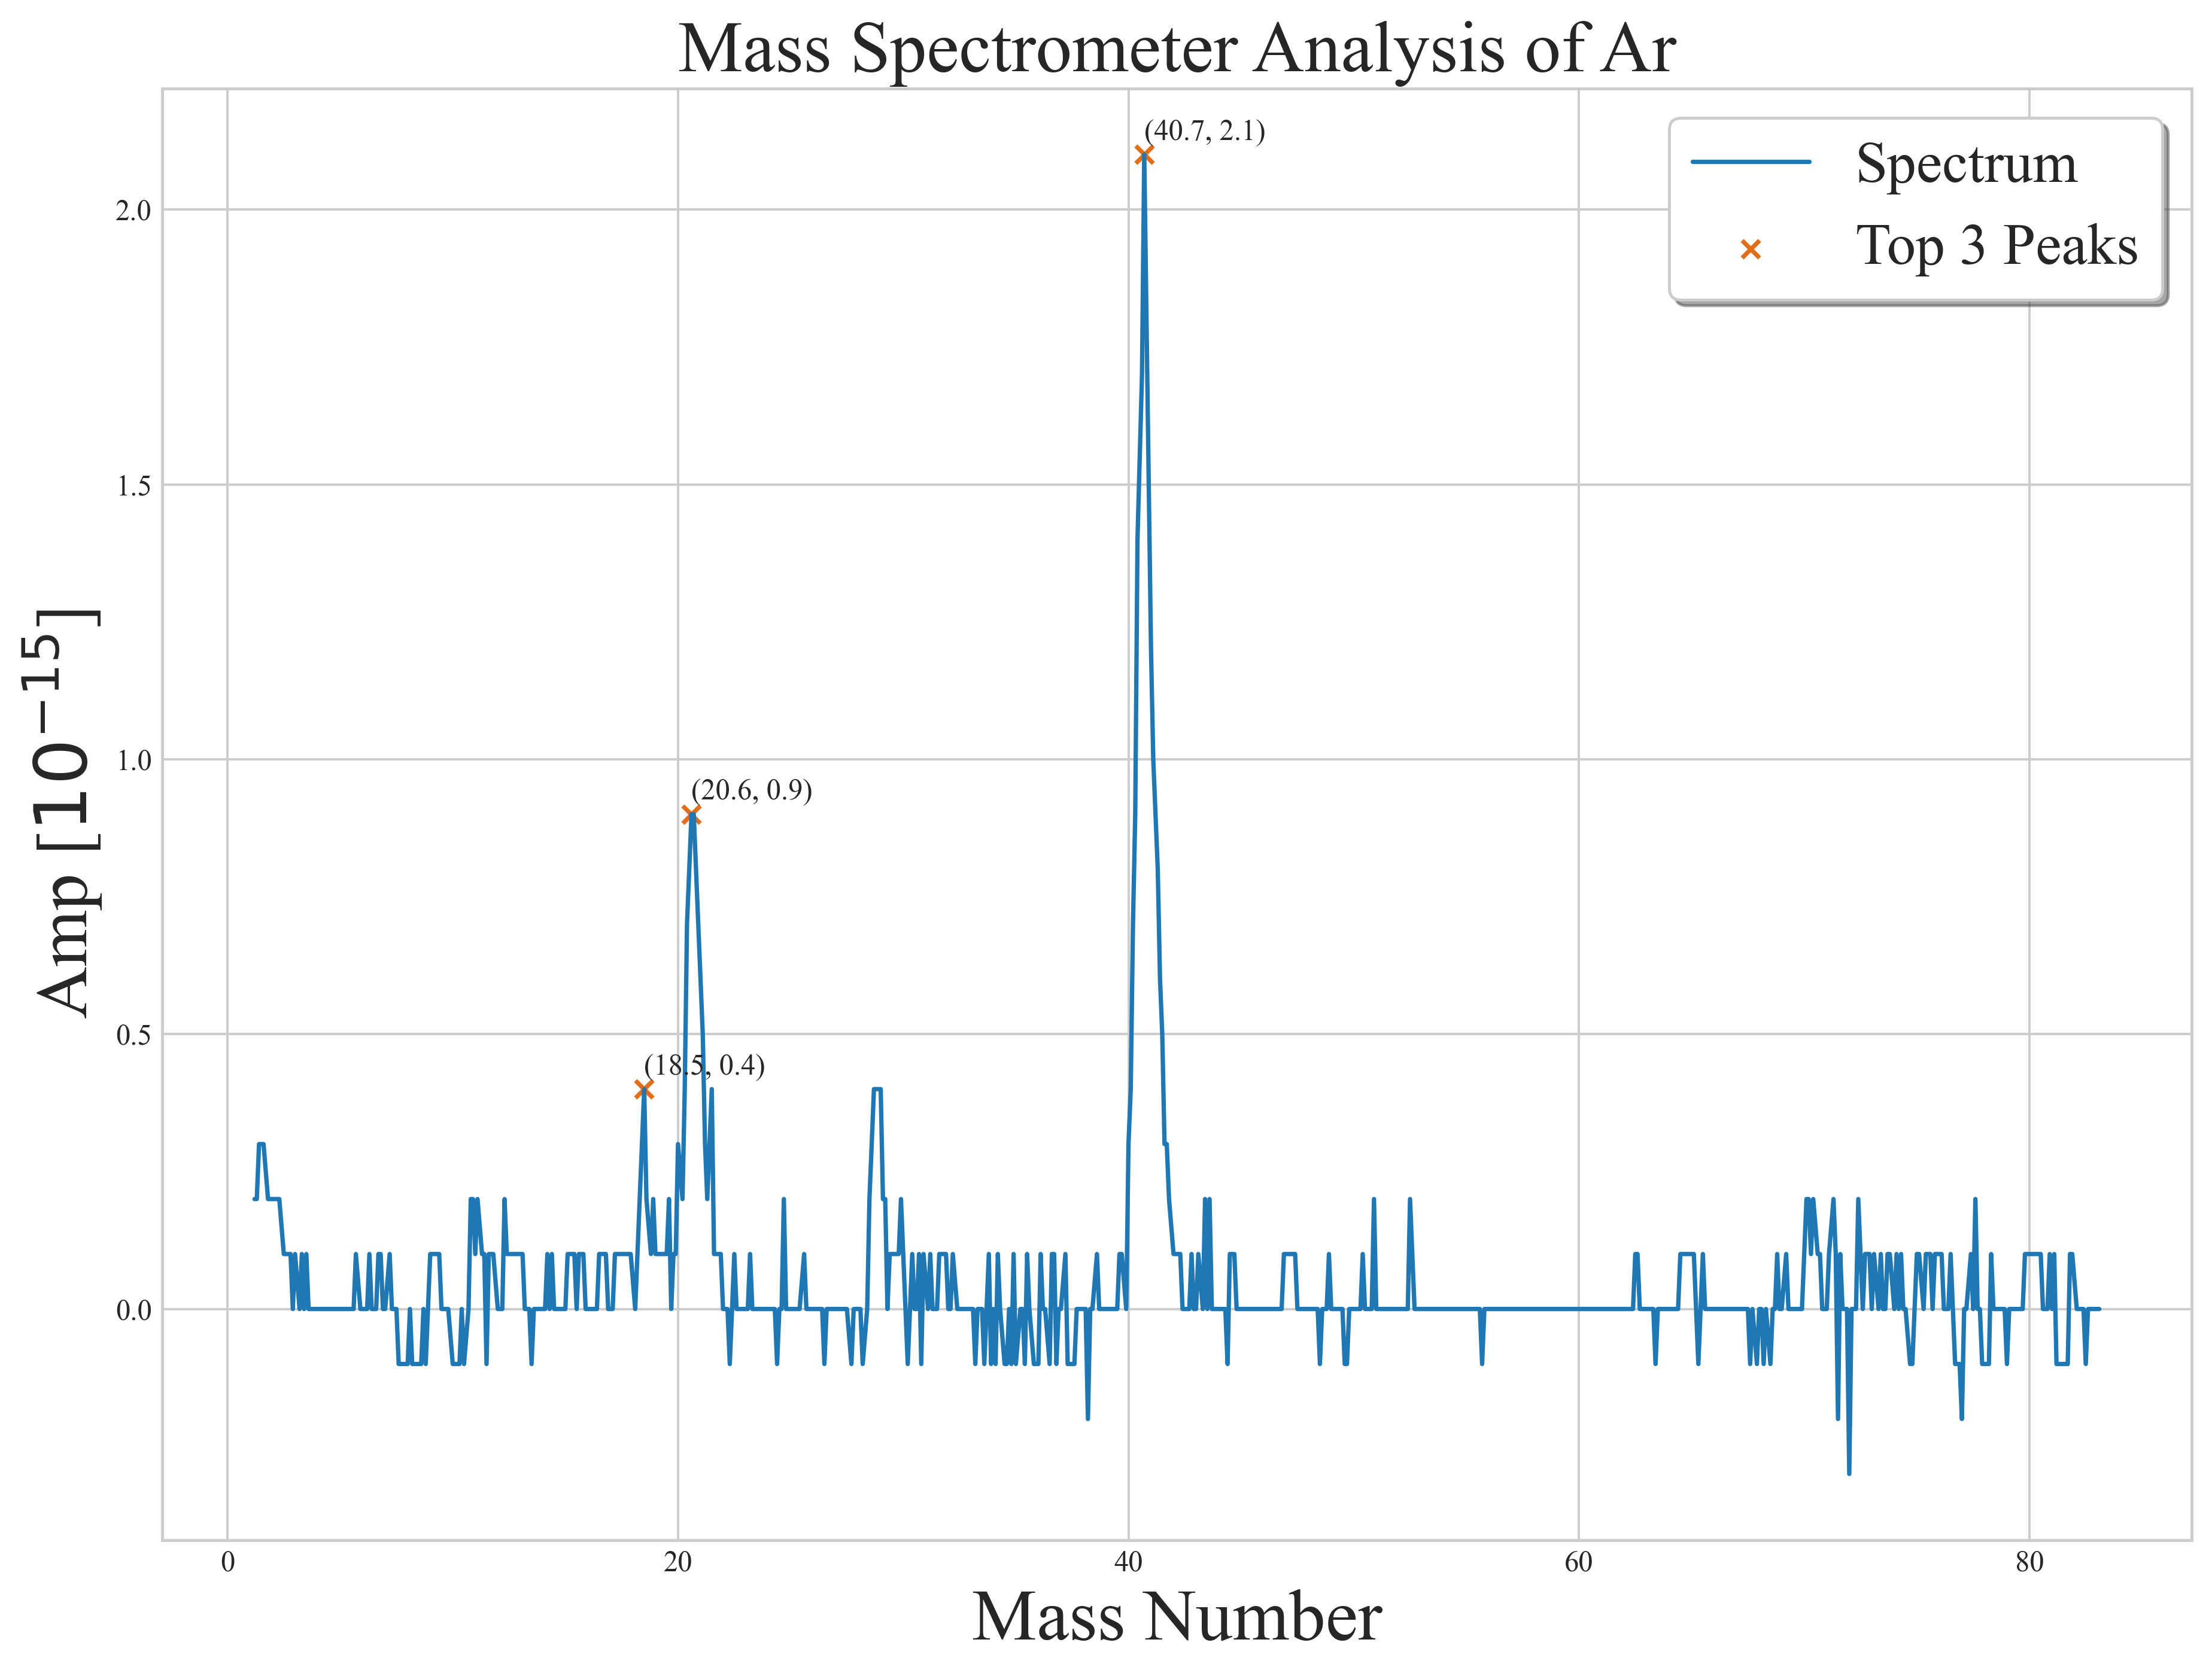

In [ ]:
data4_Ar = np.loadtxt('Ar_1.xls', skiprows=6)
mass_Ar = data4_Ar[:, 0]
amp_Ar = data4_Ar[:, 1]
mass_Ar = mass_Ar[:2*len(mass_Ar)//3]
amp_Ar = amp_Ar[:2*len(amp_Ar)//3]

# 数据加载
wavelength = mass_Ar
intensity = (amp_Ar - amp_bg)*1e15

# 设置阈值，`height` 控制峰值最低高度，`prominence` 控制突出程度
peaks, properties = find_peaks(intensity, height=0.1, prominence=0.05)

# 根据强度排序，选择强度最高的 3 个峰
sorted_indices = np.argsort(properties['peak_heights'])[-3:]  # 最后3个最高峰的索引
main_peaks = peaks[sorted_indices]  # 对应的峰位置

# 绘制光谱图及标注峰值位置
plt.figure()
plt.plot(wavelength, intensity, label="Spectrum")
plt.scatter(wavelength[main_peaks], intensity[main_peaks], color=yp.firefly()[3], label="Top 3 Peaks", marker='x')
# 标注前三强度的峰的波长
for peak in main_peaks:
    plt.annotate('({}, {})'.format(round(wavelength[peak], 2), round(intensity[peak], 2)), xy=(wavelength[peak], intensity[peak]),
                 xytext=(0, 5), textcoords='offset points')  
plt.xlabel("Mass Number")
plt.ylabel("Amp [$10^{-15}$]")
plt.title("Mass Spectrometer Analysis of Ar", fontsize=25)
plt.legend(fontsize=20, frameon=True, shadow=True)
plt.show()

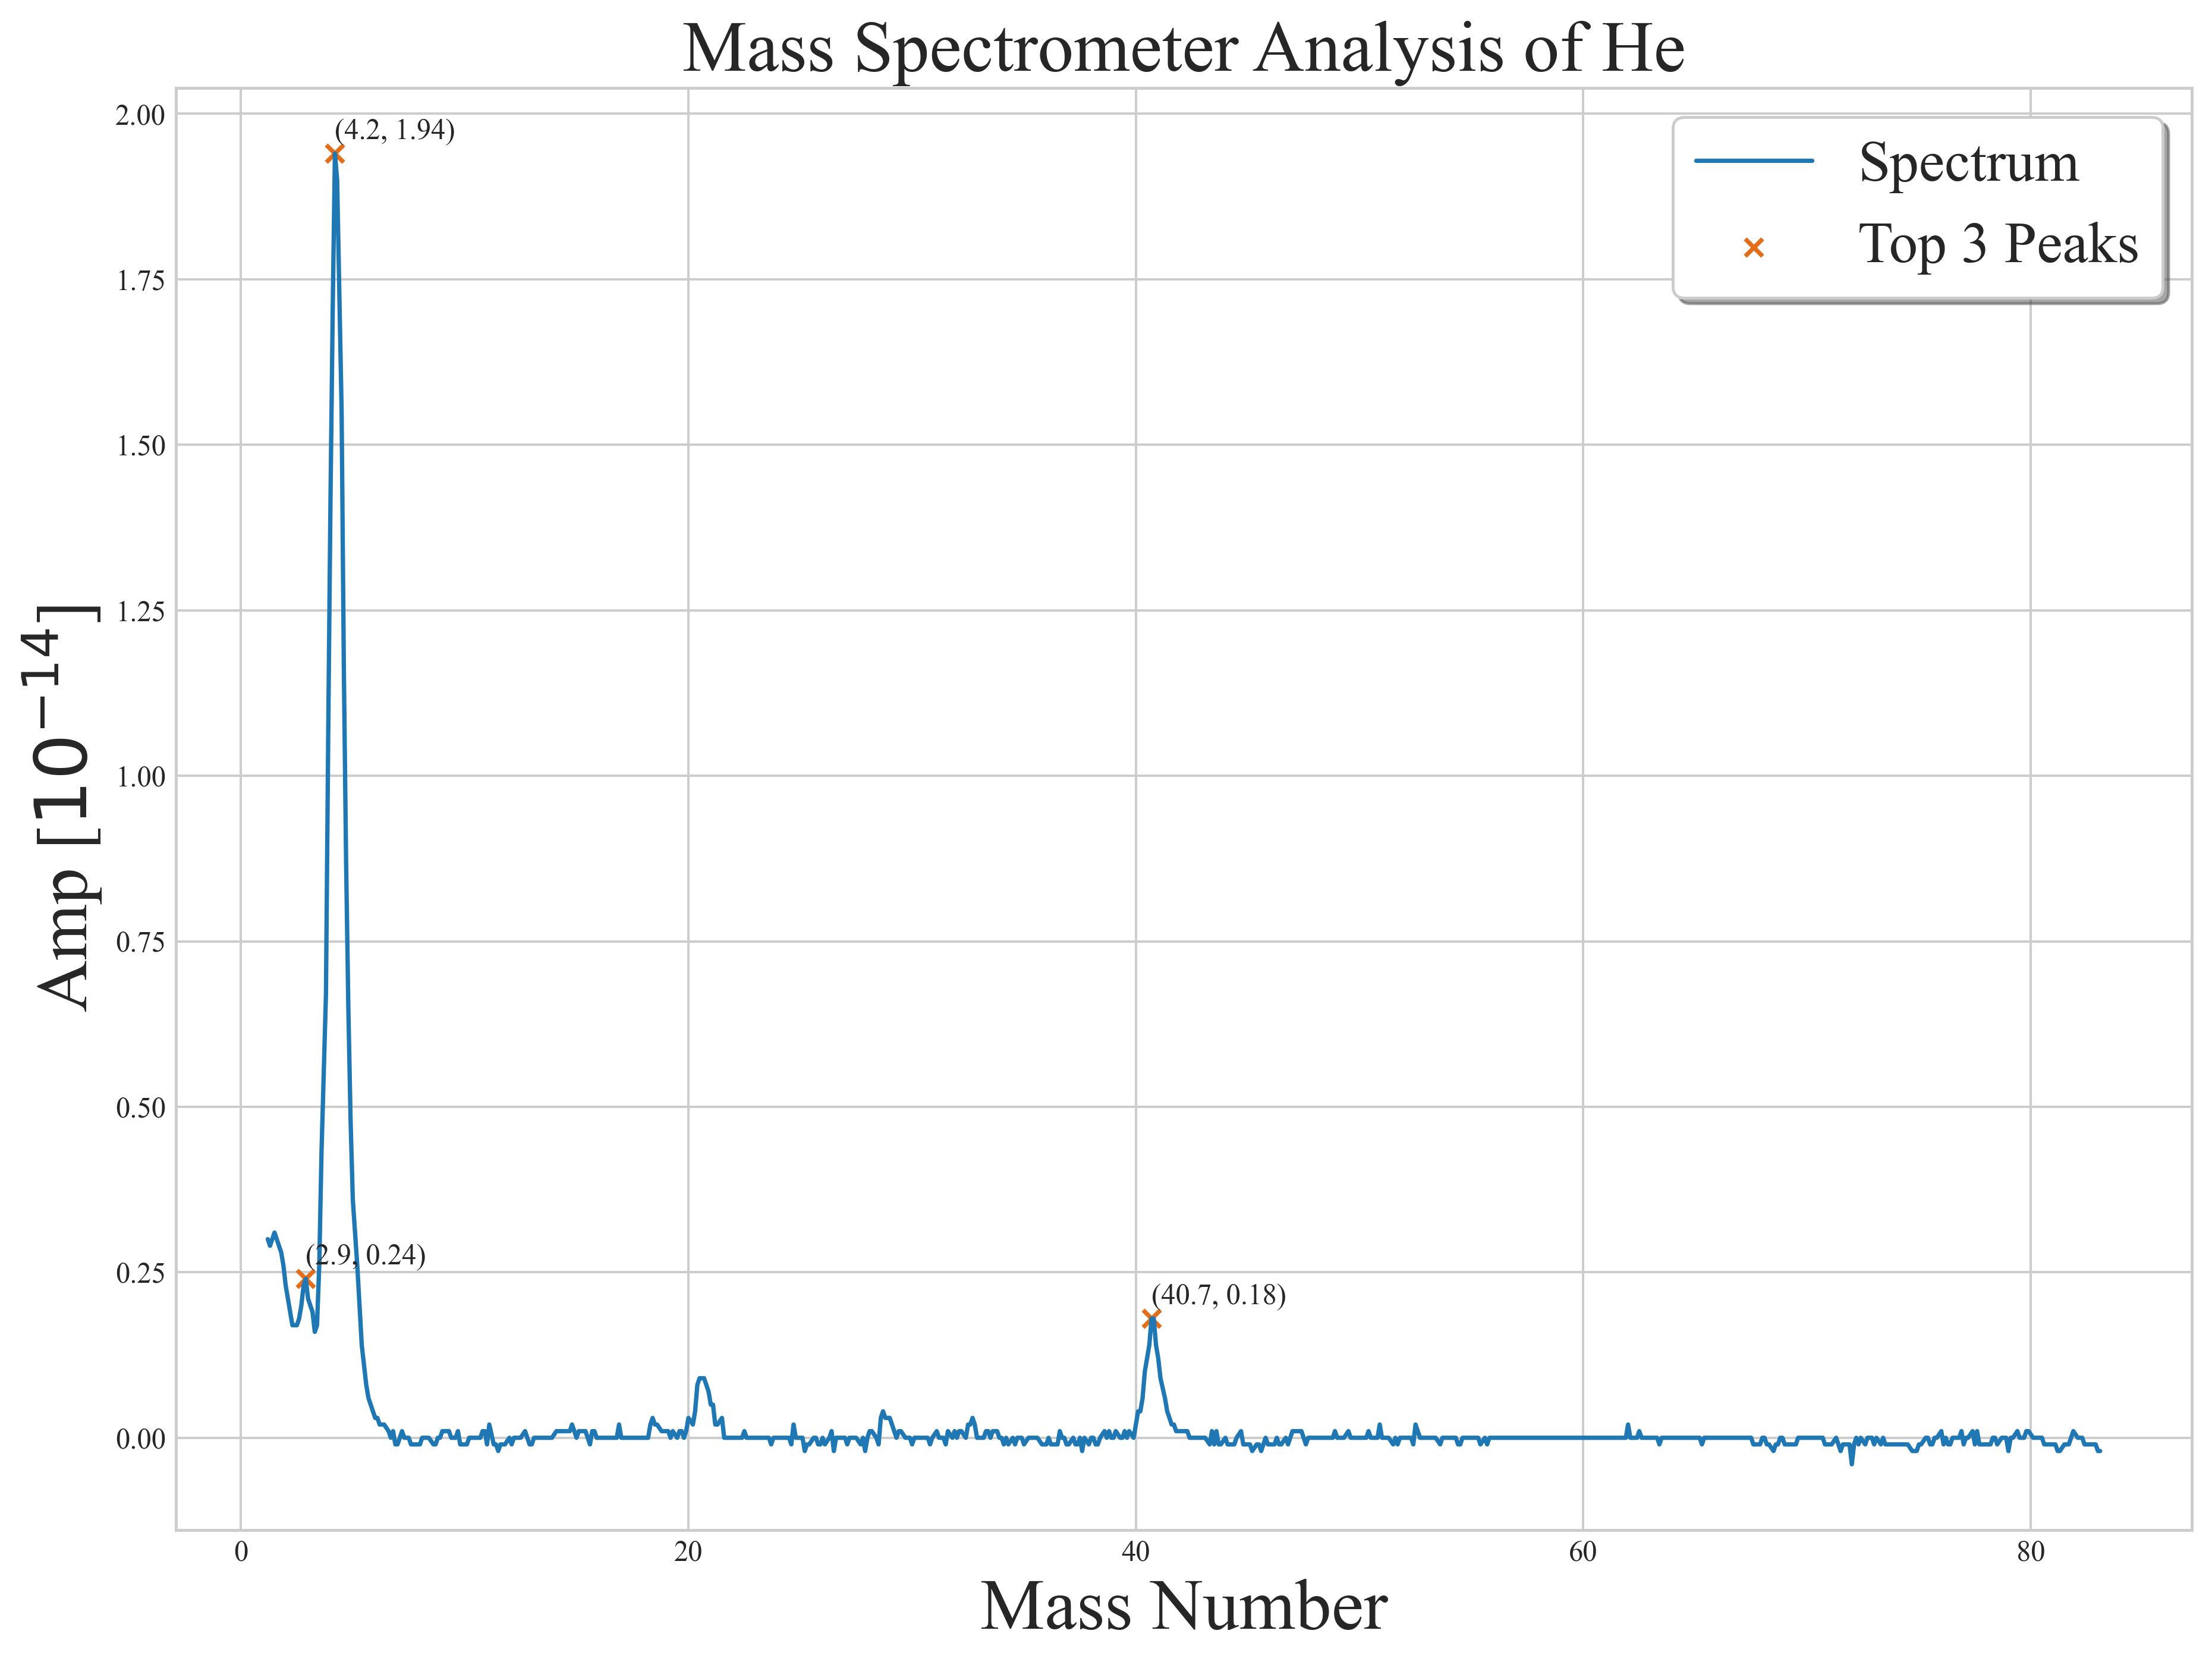

In [94]:
data4_He = np.loadtxt('He_2.xls', skiprows=6)
mass_He = data4_He[:, 0]
amp_He = data4_He[:, 1]
mass_He = mass_He[:2*len(mass_He)//3]
amp_He = amp_He[:2*len(amp_He)//3]

# 数据加载
wavelength = mass_He
intensity = (amp_He - amp_bg)*1e14

# 设置阈值，`height` 控制峰值最低高度，`prominence` 控制突出程度
peaks, properties = find_peaks(intensity, height=0.1, prominence=0.05)

# 根据强度排序，选择强度最高的 3 个峰
sorted_indices = np.argsort(properties['peak_heights'])[-3:]  # 最后3个最高峰的索引
main_peaks = peaks[sorted_indices]  # 对应的峰位置

# 绘制光谱图及标注峰值位置
plt.figure()
plt.plot(wavelength, intensity, label="Spectrum")
plt.scatter(wavelength[main_peaks], intensity[main_peaks], color=yp.firefly()[3], label="Top 3 Peaks", marker='x')
# 标注前三强度的峰的波长
for peak in main_peaks:
    plt.annotate('({}, {})'.format(round(wavelength[peak], 2), round(intensity[peak], 2)), xy=(wavelength[peak], intensity[peak]),
                 xytext=(0, 5), textcoords='offset points')  
plt.xlabel("Mass Number")
plt.ylabel("Amp [$10^{-14}$]")
plt.title("Mass Spectrometer Analysis of He", fontsize=25)
plt.legend(fontsize=20, frameon=True, shadow=True)
plt.show()

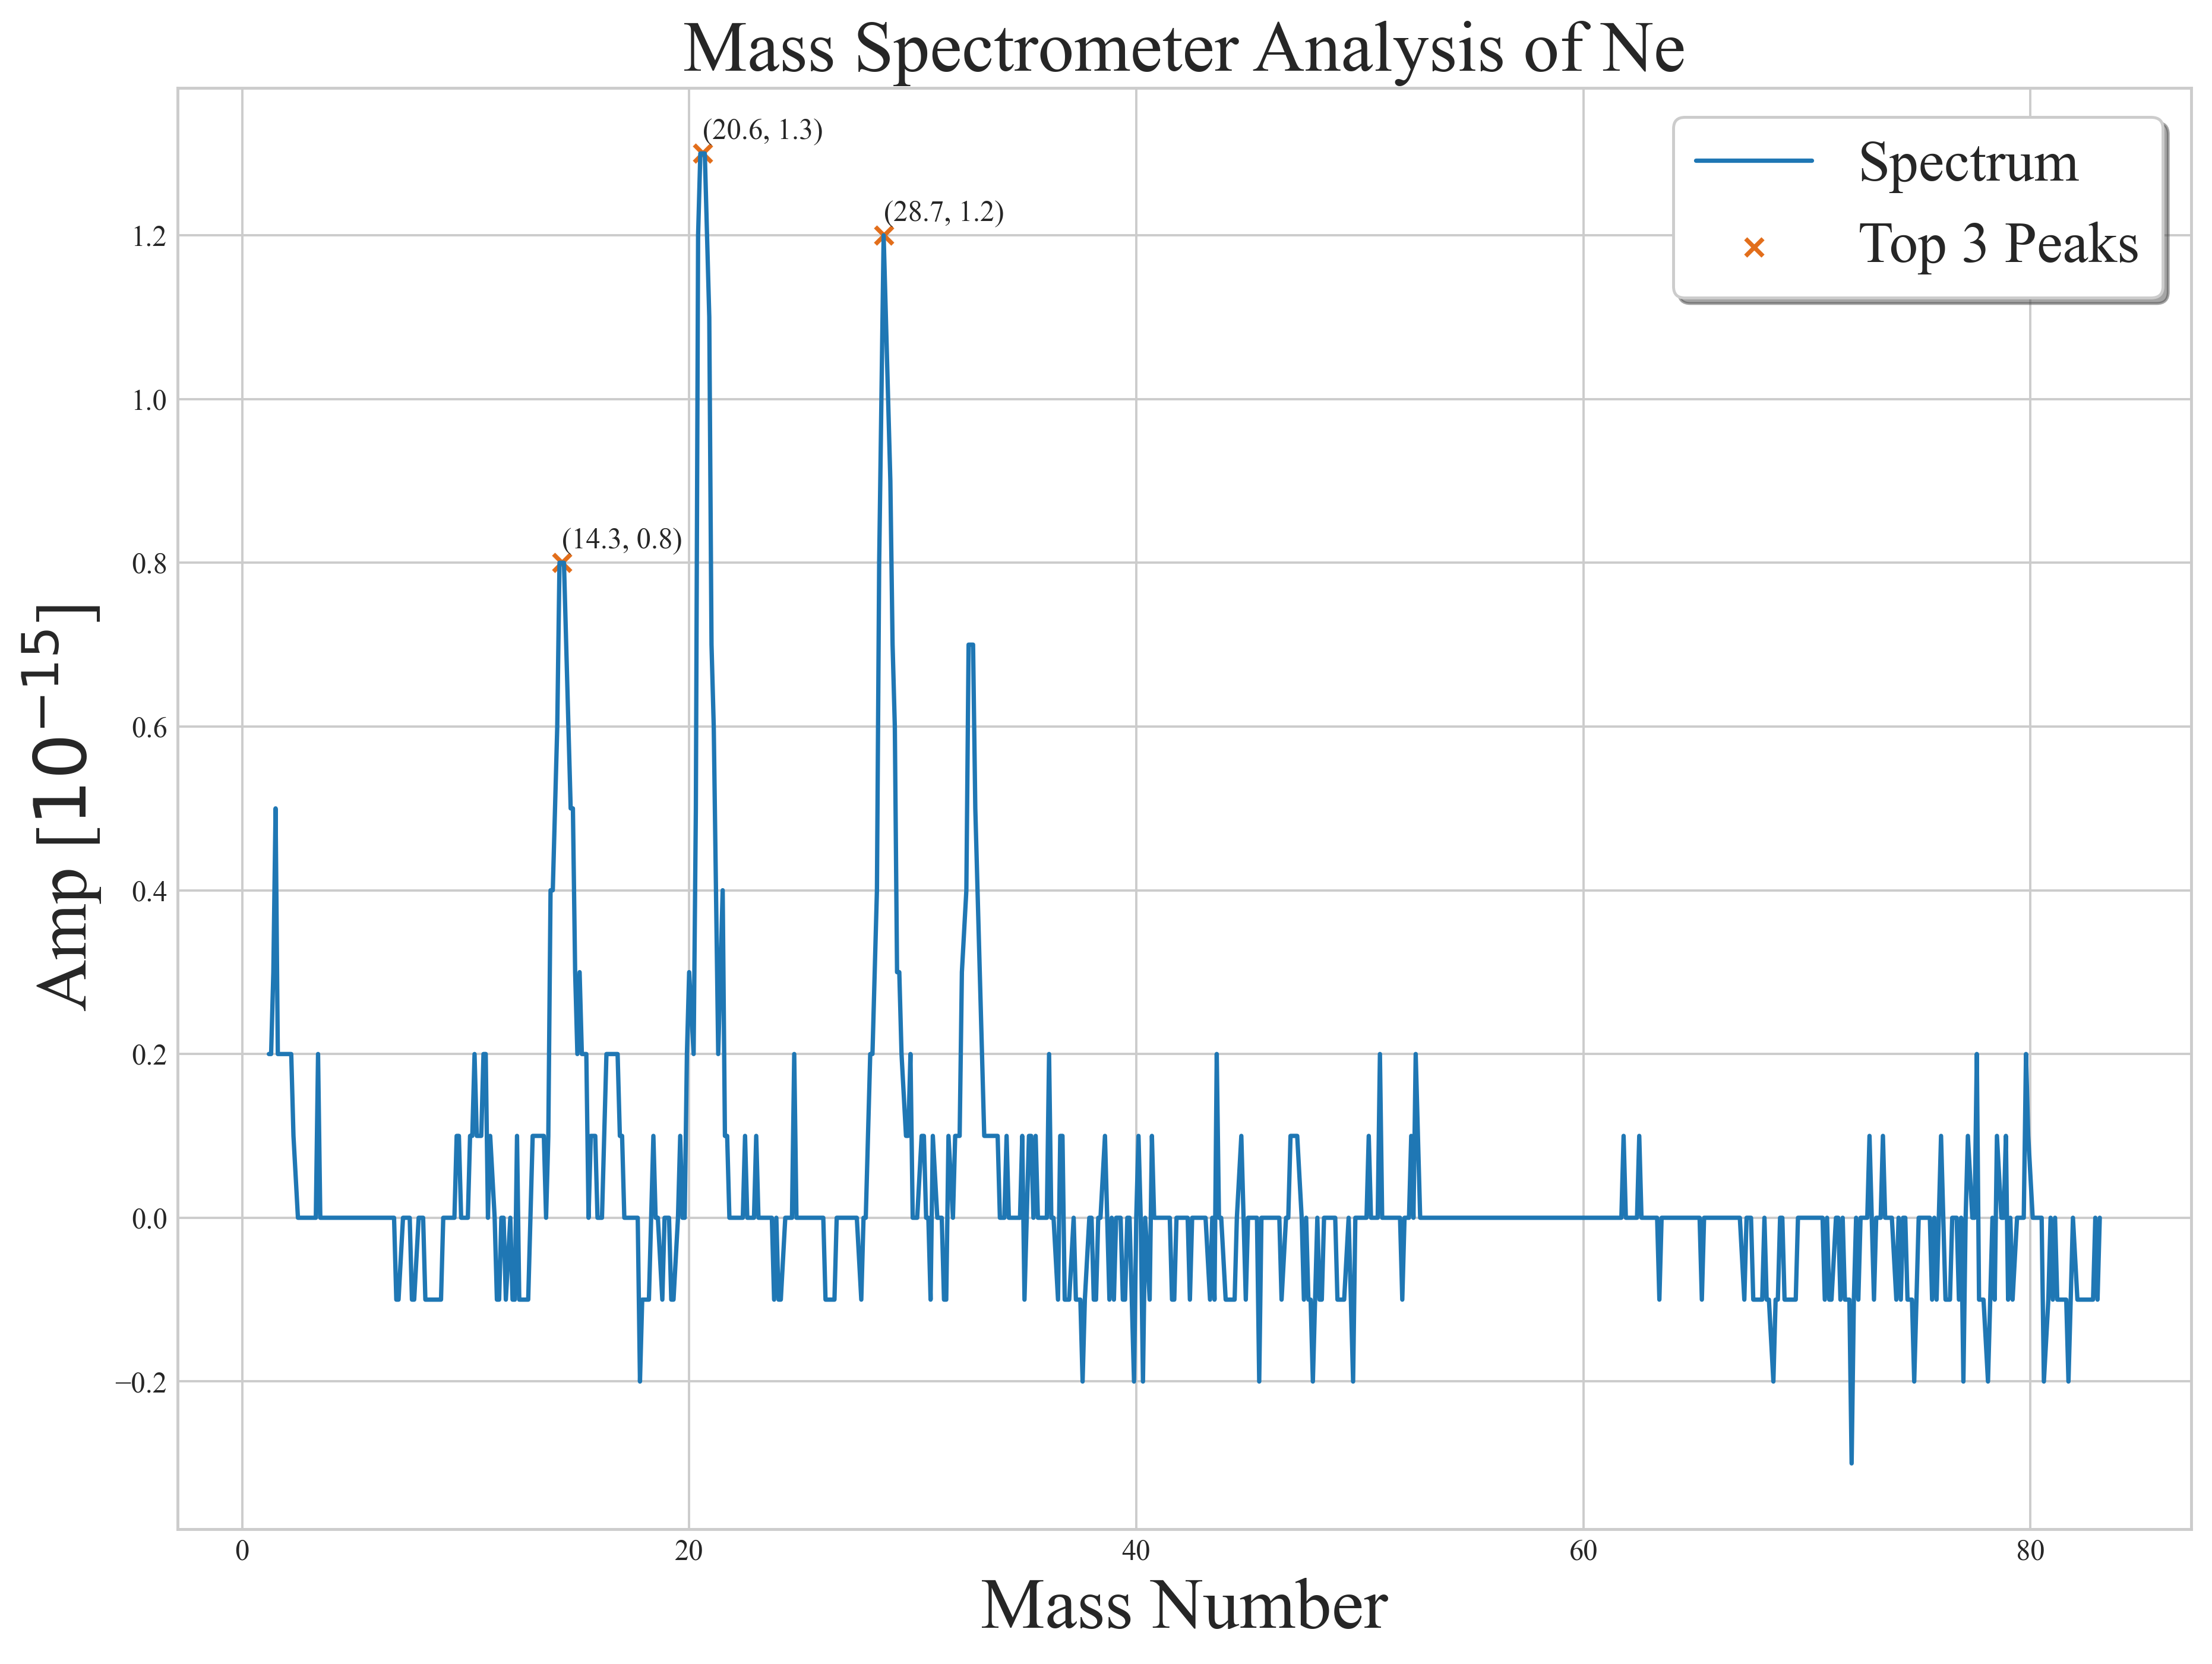

In [96]:
data4_Ne = np.loadtxt('Ne_2.xls', skiprows=6)
mass_Ne = data4_Ne[:, 0]
amp_Ne = data4_Ne[:, 1]
mass_Ne = mass_Ne[:2*len(mass_Ne)//3]
amp_Ne = amp_Ne[:2*len(amp_Ne)//3]

# 数据加载
wavelength = mass_Ne
intensity = (amp_Ne - amp_bg)*1e15

# 设置阈值，`height` 控制峰值最低高度，`prominence` 控制突出程度
peaks, properties = find_peaks(intensity, height=0.1, prominence=0.05)

# 根据强度排序，选择强度最高的 3 个峰
sorted_indices = np.argsort(properties['peak_heights'])[-3:]  # 最后3个最高峰的索引
main_peaks = peaks[sorted_indices]  # 对应的峰位置

# 绘制光谱图及标注峰值位置
plt.figure()
plt.plot(wavelength, intensity, label="Spectrum")
plt.scatter(wavelength[main_peaks], intensity[main_peaks], color=yp.firefly()[3], label="Top 3 Peaks", marker='x')
# 标注前三强度的峰的波长
for peak in main_peaks:
    plt.annotate('({}, {})'.format(round(wavelength[peak], 2), round(intensity[peak], 2)), xy=(wavelength[peak], intensity[peak]),
                 xytext=(0, 5), textcoords='offset points')  
plt.xlabel("Mass Number")
plt.ylabel("Amp [$10^{-15}$]")
plt.title("Mass Spectrometer Analysis of Ne", fontsize=25)
plt.legend(fontsize=20, frameon=True, shadow=True)
plt.show()